# Intelligent Network Intrusion Detection — Model Development

**Dataset:** CIC-IDS2017 (prepared extract) | **Task:** binary classification of network flows (benign vs attack)
**Models:** Logistic Regression (class-weighted) · LightGBM · Autoencoder (benign-trained anomaly detector)
**Model-selection metric:** validation average precision (AP). Accuracy is shown for reference only.

| Section | Contents |
|---|---|
| A | Setup and data loading |
| B | Target definition and leakage-column removal |
| C | Duplicate handling, splitting, feature selection and preprocessing |
| D | Evaluation framework |
| E | Model development (incl. exploratory Autoencoder bottleneck comparison) |
| F | Threshold selection on validation |
| G | Test-set model comparison |
| H | Validity checks |
| I | Per-attack-family analysis and exploratory family-exclusion experiment |
| J | Final model report |
| K | Saving artifacts |
| L | Export tables and figures for the report |

## Input data and project scope
This notebook starts from `data/processed/cic_ids2017_cleaned_v2.parquet`, which is produced from the raw CIC-IDS2017 CSV files by `notebooks/01_eda_and_data_preparation.ipynb`. Run that notebook first.

Run from the project root or from `notebooks/` after installing `requirements.txt`. Data, trained models and large artifacts are not committed to Git.

Steps performed here: label validation, leakage-column removal, infinity handling, removal of repeated and label-conflicting feature patterns, stratified 60/20/20 split, train-only feature selection, median imputation, quantile transformation, three models, validation-only threshold/model selection, test reporting, per-family analysis and exploratory experiments.

## Outputs
Result tables are written to `results/model_development/tables/`, figures to `results/model_development/figures/`, and models plus `config.json` to `models/`. Section L collects all tables and figures in `results/model_development/report_assets.html` for copy-paste into the report.

---
# Section A — Setup and Data Loading

In [5]:
# Report Python and library versions (TensorFlow may be installed as tensorflow-cpu or tensorflow-macos).
# Install the pinned dependencies first:  pip install -r requirements.txt
import importlib.metadata
import platform

def package_version(*distribution_names):
    """Return the installed version of the first distribution name that is found."""
    for name in distribution_names:
        try:
            return importlib.metadata.version(name)
        except importlib.metadata.PackageNotFoundError:
            continue
    return "not installed"

PACKAGES = {
    "numpy": ("numpy",),
    "pandas": ("pandas",),
    "scikit-learn": ("scikit-learn",),
    "lightgbm": ("lightgbm",),
    "tensorflow": ("tensorflow", "tensorflow-cpu", "tensorflow-macos"),
    "keras": ("keras",),
    "matplotlib": ("matplotlib",),
    "seaborn": ("seaborn",),
    "joblib": ("joblib",),
    "pyarrow": ("pyarrow",),
}
LIBRARY_VERSIONS = {label: package_version(*names) for label, names in PACKAGES.items()}

print(f"Python {platform.python_version()} on {platform.system()} {platform.machine()}")
for label, version in LIBRARY_VERSIONS.items():
    print(f"  {label:<13} {version}")

Python 3.12.14 on Darwin arm64
  numpy         2.5.3
  pandas        3.0.6
  scikit-learn  1.9.1
  lightgbm      4.7.0
  tensorflow    2.21.0
  keras         3.15.1
  matplotlib    3.11.2
  seaborn       0.13.2
  joblib        1.6.0
  pyarrow       25.0.1


In [6]:
import gc
import os
import json
import time
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer

# Reduce TensorFlow C++ log noise; must be set before TensorFlow is imported.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

# Keep warnings visible so convergence and compatibility issues can be reviewed.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 100)

# Fixed seed for repeatable splits; exact numerical results also depend on the environment.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


## A.1 Configuration

Core settings are collected here; model-specific parameters remain next to their model definitions and are recorded when artifacts are saved.

In [7]:
# --- Paths ---
# Paths are resolved from the project root in A.2.
CLEANED_FILE = "cic_ids2017_cleaned_v2.parquet"   # written by notebooks/01_eda_and_data_preparation.ipynb

# --- Reference dataset size, used to verify the correct file was loaded ---
EXPECTED_ROWS = 2_830_743
# SHA-256 of the reference v2 checkpoint; other pandas/pyarrow versions may write different bytes.
REFERENCE_SHA256 = "58d779aa6f861d4d3ad998e27fed8bdbed8d2b861856445b6ff6b1d102619f58"

# --- Feature selection (fitted on the training set only, Section C.4) ---
CORRELATION_THRESHOLD = 0.95   # drop one of any feature pair above this correlation

# --- Data splitting ---
TEST_SIZE = 0.20               # test share of the full dataset
VAL_SIZE = 0.25                # validation share of the remaining 80% -> 20% overall

# --- Exploratory attack-family exclusion (Section I.1) ---
# Removed from classifier training only; shared preprocessing still sees it (exploratory).
HELD_OUT_ATTACK = "FTP-Patator"

# --- Autoencoder ---
BOTTLENECK_SIZE = 16
AE_EPOCHS = 30
AE_BATCH_SIZE = 512

# --- Columns that must never enter the feature matrix ---
# Each of these is derived from the target and would leak the answer to the model.
LEAKY_COLUMNS = ["Label", "Label_binary", "source_file"]

## A.2 Load the prepared dataset

Loads `data/processed/cic_ids2017_cleaned_v2.parquet` (written by notebook 01), checks its row count and records its SHA-256 fingerprint.

In [8]:
# Load the cleaned v2 checkpoint written by notebook 01.
# Expected location: data/processed/cic_ids2017_cleaned_v2.parquet
import hashlib

# Run the kernel from the project root (or its notebooks/ folder).
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Cleaned dataset location
CLEANED_PATH = PROJECT_ROOT / "data" / "processed" / CLEANED_FILE

if not CLEANED_PATH.is_file():
    raise FileNotFoundError(
        f"Could not find the cleaned dataset at: "
        f"{CLEANED_PATH.relative_to(PROJECT_ROOT)}. Run notebooks/01_eda_and_data_preparation.ipynb first."
    )

# Output directories
OUTPUT_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results" / "model_development"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

for directory in (OUTPUT_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Fingerprint the input dataset
with CLEANED_PATH.open("rb") as stream:
    DATA_SHA256 = hashlib.file_digest(stream, "sha256").hexdigest()

print(f"Input   : {CLEANED_PATH.relative_to(PROJECT_ROOT)}")
print(f"SHA-256 : {DATA_SHA256}")

if DATA_SHA256 != REFERENCE_SHA256:
    print(
        "WARNING: fingerprint differs from the reference file; "
        "results will not match the recorded run."
    )

# Load cleaned dataset
df = pd.read_parquet(CLEANED_PATH)
df.columns = df.columns.str.strip()

# Release unused Arrow memory (about 2 GB after reading this file)
import pyarrow as pa
pa.default_memory_pool().release_unused()

print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# Check that this is the team's reference dataset
if df.shape[0] != EXPECTED_ROWS:
    print(
        f"\nWARNING: expected {EXPECTED_ROWS:,} rows but found {df.shape[0]:,}. "
        "This is not the team's reference dataset."
    )
else:
    print("\nRow count matches the team's reference dataset.")

print("Column names:", df.columns.tolist())

assert df.columns.is_unique, "Duplicate column names after stripping whitespace."
assert "Label" in df.columns, "Required Label column is missing."

Input   : data/processed/cic_ids2017_cleaned_v2.parquet
SHA-256 : 58d779aa6f861d4d3ad998e27fed8bdbed8d2b861856445b6ff6b1d102619f58

Rows    : 2,830,743
Columns : 80

Row count matches the team's reference dataset.
Column names: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Ma

---
# Section B — Feature Engineering and Selection

CIC-IDS2017 already provides 78 engineered flow statistics, so this section performs **selection rather than construction**: removing columns that leak the target, carry no information, or duplicate others.

## B.1 Define the binary target

Everything that is not `BENIGN` becomes the positive class. The original attack labels are kept separately for the per-family analysis in Section I; they never enter training.

In [9]:
# Validate labels before building the binary target.
# Retained for per-attack-family analysis only; never used as a feature.
assert df["Label"].notna().all(), "Missing labels must be resolved before modelling."
original_labels = df["Label"].astype(str).str.strip().copy()
assert original_labels.ne("").all(), "Empty labels found."
assert original_labels.eq("BENIGN").any(), "BENIGN label is missing."

y = (original_labels != "BENIGN").astype(int)

n_benign, n_attack = (y == 0).sum(), (y == 1).sum()

print("Binary target distribution")
print(f"  BENIGN (0) : {n_benign:>10,}  ({n_benign / len(y):.2%})")
print(f"  ATTACK (1) : {n_attack:>10,}  ({n_attack / len(y):.2%})")
print(f"\nImbalance ratio: 1 attack per {n_benign / n_attack:.1f} benign flows")
print("\nOriginal label breakdown:")
print(original_labels.value_counts())

Binary target distribution
  BENIGN (0) :  2,273,097  (80.30%)
  ATTACK (1) :    557,646  (19.70%)

Imbalance ratio: 1 attack per 4.1 benign flows

Original label breakdown:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


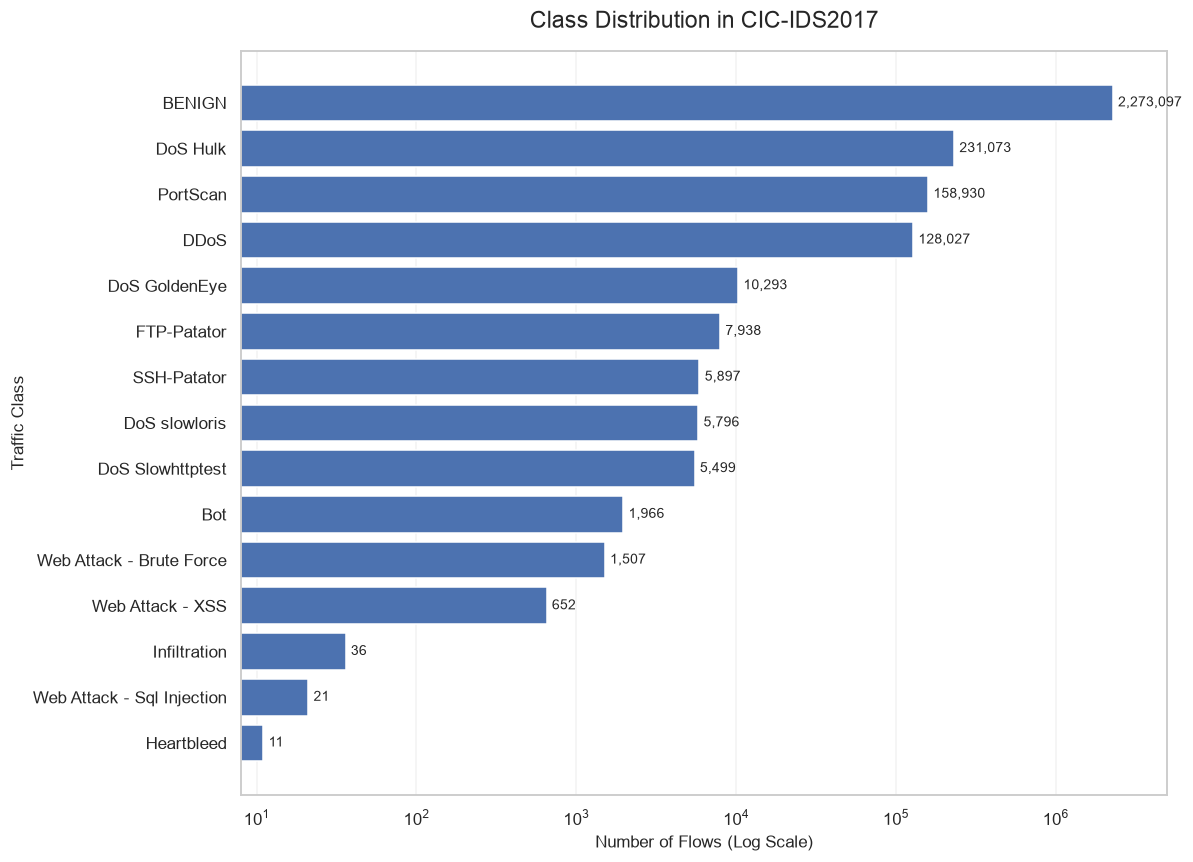

In [10]:
# Figure 1 — CIC-IDS2017 Class Distribution (Log Scale)

# Count original traffic classes
class_counts = original_labels.value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))

# Horizontal bars
bars = ax.barh(
    class_counts.index,
    class_counts.values
)

# Logarithmic scale
ax.set_xscale("log")

# Titles and labels
ax.set_title(
    "Class Distribution in CIC-IDS2017",
    fontsize=15,
    pad=15
)

ax.set_xlabel(
    "Number of Flows (Log Scale)",
    fontsize=11
)

ax.set_ylabel(
    "Traffic Class",
    fontsize=11
)

# Add the actual number of flows next to each bar
for bar, count in zip(bars, class_counts.values):
    ax.text(
        count * 1.08,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=9
    )

# Give labels enough space on the right
ax.set_xlim(
    8,
    class_counts.max() * 2.2
)

# Light grid only on the value axis
ax.grid(
    axis="x",
    which="major",
    alpha=0.25
)

ax.grid(
    axis="y",
    visible=False
)

plt.tight_layout()

# High-resolution version for the report
plt.savefig(
    FIGURES_DIR / "figure01_class_distribution_log_scale.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

*Output: the overall imbalance is roughly 1 attack per 4 benign flows, but the per-family breakdown shows far more extreme scarcity in the rarest classes.*

## B.2 Remove leakage sources

| Column | Why it leaks |
|---|---|
| `Label` | The target itself |
| `Label_binary` | Derived directly from `Label` |
| `source_file` | Capture day; several days contain only one attack scenario |

In [11]:
# Report non-numeric columns instead of dropping them silently.
dropped_leaky = [col for col in LEAKY_COLUMNS if col in df.columns]

X = df.drop(columns=dropped_leaky)
excluded_text_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Excluded non-numeric columns:", excluded_text_columns)
X = X.select_dtypes(include=[np.number])  # any remaining text column cannot be modelled directly

del df
gc.collect()

print(f"Excluded as leakage : {dropped_leaky}")
print(f"Features remaining  : {X.shape[1]}")

Excluded non-numeric columns: []
Excluded as leakage : ['Label', 'source_file']
Features remaining  : 78


In [12]:
# Name scan only; it cannot prove that leakage is absent.
def check_for_leakage(columns):
    """Flag any column whose name suggests it is derived from the target.

    Args:
        columns: iterable of column names to inspect.

    Returns:
        List of suspicious column names (empty if the check passes).
    """
    keywords = ("label", "target", "class", "attack", "benign")
    return [c for c in columns if any(k in c.lower() for k in keywords)]

suspicious = check_for_leakage(X.columns)

if suspicious:
    print(f"WARNING — potential leakage columns still present: {suspicious}")
else:
    print("Name scan found no suspicious names; this does not prove absence of leakage.")

Name scan found no suspicious names; this does not prove absence of leakage.


*This name scan is a preliminary check, not proof that all leakage is absent.*

---
# Section C — Data Splitting and Preprocessing

**Rule:** anything that reads values out of the data — a median, a set of quantiles, or a
list of columns to drop — is fitted on the training set and then applied unchanged to
validation and test. The duplicate/conflict policy below is an explicit dataset-level exception: it uses labels to exclude ambiguous patterns before splitting. Reported results therefore apply to this filtered population, not all original flows.

| Step | Timing |
|---|---|
| Drop leakage columns | Before split — fixed list |
| Infinity to `NaN` | Before split — row-wise |
| Collapse duplicate flow patterns | Before split — dataset-level, no fitted value |
| Drop constant features | After split — fitted on train |
| Drop redundant features | After split — fitted on train |
| Impute | After split — fitted on train |
| Scale | After split — fitted on train |

## C.1 Handle infinite values

Rate features such as `Flow Bytes/s` become `Infinity` when flow duration is zero. These are converted to `NaN` and imputed after the split. Float precision is preserved until duplicate patterns are identified; imputed model arrays are subsequently converted to float32.

In [13]:
# Float precision is kept until duplicate detection (C.2).
X = X.replace([np.inf, -np.inf], np.nan)

missing_cells = int(X.isnull().sum().sum())
affected_rows = int(X.isnull().any(axis=1).sum())

print(f"Missing cells : {missing_cells:,}")
print(f"Rows affected : {affected_rows:,} ({affected_rows / len(X):.4%})")

Missing cells : 9,314
Rows affected : 5,792 (0.2046%)


## C.2 Collapse duplicate flow patterns

Flood-based attacks produce long runs of flows whose measured features are byte-for-byte
identical. Under a random split the same pattern lands in both training and test, so part
of the test score measures recall of memorised rows rather than generalisation.

Each distinct feature vector is kept once. Two cases are handled explicitly:

- **Repeated patterns with a consistent label** — one representative is kept.
- **Repeated patterns with conflicting labels** — the same measurements appear as both
  benign and attack. No model can separate these, and keeping either copy would assign an
  arbitrary label, so the whole pattern is removed and the count reported.

Patterns are compared with a 64-bit row hash at the original float64 precision (after infinities become NaN). This step uses labels before the split, so every reported metric applies to this de-duplicated, conflict-free population.

In [14]:
# One hash per distinct feature vector.
feature_hash = pd.util.hash_pandas_object(X, index=False).values

pattern = pd.DataFrame({"hash": feature_hash, "attack": y.values})
grouped = pattern.groupby("hash")["attack"]
group_size = grouped.transform("size").values
group_attacks = grouped.transform("sum").values

# A pattern is contradictory if its rows carry both labels.
conflicting = (group_attacks > 0) & (group_attacks < group_size)
first_occurrence = ~pd.Series(feature_hash).duplicated(keep="first").values
keep = first_occurrence & ~conflicting

rows_before = len(X)
rate_before = y.mean()
n_repeated = int((~first_occurrence & ~conflicting).sum())
n_conflicting_rows = int(conflicting.sum())
n_conflicting_patterns = int(pd.Series(feature_hash[conflicting]).nunique())

X = X.loc[keep].reset_index(drop=True)
y = y.loc[keep].reset_index(drop=True)
original_labels = original_labels.loc[keep].reset_index(drop=True)
feature_hash = feature_hash[keep]

del pattern, grouped, group_size, group_attacks, conflicting, first_occurrence, keep
gc.collect()

print(f"Rows before                       : {rows_before:,}")
print(f"Removed as repeated copies        : {n_repeated:,}")
print(f"Removed as contradictory patterns : {n_conflicting_rows:,} "
      f"(across {n_conflicting_patterns:,} patterns)")
print(f"Rows remaining                    : {len(X):,}")
print(f"\nAttack rate: {rate_before:.2%} -> {y.mean():.2%}")

Rows before                       : 2,830,743
Removed as repeated copies        : 302,757
Removed as contradictory patterns : 7,020 (across 698 patterns)
Rows remaining                    : 2,520,966

Attack rate: 19.70% -> 16.87%


*Output: the attack rate moves after this step because flood families contribute most of
the repeated rows. The dataset becomes smaller and less imbalanced, and every remaining
row is a distinct flow pattern.*

## C.3 Stratified three-way split

**60% train / 20% validation / 20% test.**

Three sets rather than two because the decision threshold is tuned by inspecting results — whichever set it is chosen on becomes contaminated.

| Set | Purpose |
|---|---|
| Train | Model parameters |
| Validation | LightGBM early stopping, threshold selection, model selection |
| Test | Reporting only, after the model and thresholds are fixed |

Splitting on **index positions** allows the original label column to be sliced with the identical test indices in Section I.

In [15]:
indices = np.arange(len(X))

# First split: hold out the test set.
train_val_idx, test_idx = train_test_split(
    indices, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Second split: divide the remainder into train and validation.
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=VAL_SIZE,
    stratify=y.iloc[train_val_idx],
    random_state=RANDOM_STATE,
)

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

# Aligned with X_test; used only for per-attack-family reporting.
labels_test = original_labels.iloc[test_idx]

del X
gc.collect()

split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Rows": [len(y_train), len(y_val), len(y_test)],
        "Attacks": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
        "Attack rate": [
            f"{y_train.mean():.2%}",
            f"{y_val.mean():.2%}",
            f"{y_test.mean():.2%}",
        ],
    }
)

print(f"Total rows accounted for: {len(y_train) + len(y_val) + len(y_test):,}")
split_summary

Total rows accounted for: 2,520,966


,Split,Rows,Attacks,Attack rate
0,Train,1512579,255108,16.87%
1,Validation,504193,85036,16.87%
2,Test,504194,85036,16.87%


*Output: the attack rate should be identical across all three splits, and the row counts should sum to the full dataset.*

### C.3.1 Independence check

Checks exact feature-pattern overlap. This does not establish independence across sessions, capture days or correlated flows. This is
asserted rather than printed, so the notebook stops if the protocol is ever broken.

In [16]:
train_patterns = np.unique(feature_hash[train_idx])
overlap = int(np.isin(feature_hash[test_idx], train_patterns).sum())

print(f"Test rows repeating a training pattern: {overlap:,}")
assert overlap == 0, "Test set overlaps the training set."

del train_patterns
gc.collect()

Test rows repeating a training pattern: 0


0

## C.4 Feature selection — fitted on the training set

Which features are constant, and which pairs are correlated, are properties of the rows
observed. Measuring them on the full dataset lets the test set decide what the models are
given. Both are measured on `X_train`, and the resulting column list is applied to the
held-out sets.

In [17]:
# Constant in training: a single distinct value carries no information.
constant_features = X_train.columns[X_train.nunique() <= 1].tolist()
X_train = X_train.drop(columns=constant_features)

# Redundant in training: of any pair above the threshold, the second is dropped.
correlation_sample = X_train.sample(n=min(100_000, len(X_train)), random_state=RANDOM_STATE)
correlation = correlation_sample.corr().abs()
upper_triangle = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))

redundant_features = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > CORRELATION_THRESHOLD)
]

X_train = X_train.drop(columns=redundant_features)
FEATURE_NAMES = X_train.columns.tolist()

X_val = X_val[FEATURE_NAMES]
X_test = X_test[FEATURE_NAMES]

del correlation_sample, correlation, upper_triangle
gc.collect()

assert list(X_val.columns) == FEATURE_NAMES == list(X_test.columns)

print(f"Constant features removed : {len(constant_features)}")
for feature in constant_features:
    print(f"  - {feature}")
print(f"\nRedundant features removed (|r| > {CORRELATION_THRESHOLD}): {len(redundant_features)}")
print(f"Final feature count: {len(FEATURE_NAMES)}")

Constant features removed : 8
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk
  - Fwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd Avg Bulk Rate

Redundant features removed (|r| > 0.95): 26
Final feature count: 44


In [18]:
# Feature reduction summary, for the report.
after_leakage = len(FEATURE_NAMES) + len(constant_features) + len(redundant_features)

reduction_summary = pd.DataFrame(
    {
        "Step": [
            "Original columns",
            "After removing leakage columns",
            "After removing constant features",
            "After removing redundant features",
        ],
        "Features remaining": [
            after_leakage + len(dropped_leaky),
            after_leakage,
            after_leakage - len(constant_features),
            len(FEATURE_NAMES),
        ],
        "Removed at this step": [
            0,
            len(dropped_leaky),
            len(constant_features),
            len(redundant_features),
        ],
    }
)
reduction_summary

,Step,Features remaining,Removed at this step
0,Original columns,80,0
1,After removing leakage columns,78,2
2,After removing constant features,70,8
3,After removing redundant features,44,26


*Output: the reduction table traces the feature count through all three removal steps.*

## C.5 Two preprocessing tracks

| Track | Used by | Processing | Reason |
|---|---|---|---|
| 1 | LightGBM | Median imputation only | Trees split on thresholds, so rescaling changes nothing |
| 2 | Logistic Regression, Autoencoder | Imputation + `QuantileTransformer` | Both are scale-sensitive |

**Median, not mean:** robust to the extreme skew in these features.

**`QuantileTransformer`, not `StandardScaler`:** scaling shifts a distribution but does not reshape it. These features have skewness above 50, so after standard scaling most points remain compressed near zero while outliers sit hundreds of standard deviations away — which dominates the Autoencoder's squared-error loss.

**`uniform`, not `normal`:** determined experimentally. Many features are zero-inflated, and under a normal output distribution every zero maps to the clipping edge near −5.2, recreating the extreme-value problem. `uniform` has a bounded range with no such edge.

In [19]:
# --- Track 1: tree models (imputation only) ---
imputer = SimpleImputer(strategy="median")

# fit_transform learns the median from training data; transform reuses it elsewhere.
X_train_tree = imputer.fit_transform(X_train).astype("float32")
X_val_tree = imputer.transform(X_val).astype("float32")
X_test_tree = imputer.transform(X_test).astype("float32")

print(f"Track 1 ready — shape {X_train_tree.shape}")

Track 1 ready — shape (1512579, 44)


In [20]:
# --- Track 2: scale-sensitive models (imputation + quantile transform) ---
quantile_transformer = QuantileTransformer(
    output_distribution="uniform",
    n_quantiles=1000,
    subsample=200_000,
    random_state=RANDOM_STATE,
)

X_train_scaled = quantile_transformer.fit_transform(X_train_tree).astype("float32")
X_val_scaled = quantile_transformer.transform(X_val_tree).astype("float32")
X_test_scaled = quantile_transformer.transform(X_test_tree).astype("float32")

del X_train, X_val, X_test
gc.collect()

print(f"Track 2 ready — shape {X_train_scaled.shape}")
print(f"  Range : [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"  Mean  : {X_train_scaled.mean():.3f}")
print(f"  Std   : {X_train_scaled.std():.3f}")

Track 2 ready — shape (1512579, 44)
  Range : [0.00, 1.00]
  Mean  : 0.363
  Std   : 0.364


### Verifying the transformation

Top row shows raw features (a single spike at zero with an invisible tail). Bottom row shows transformed values in [0, 1]; repeated or discrete values can still create spikes.

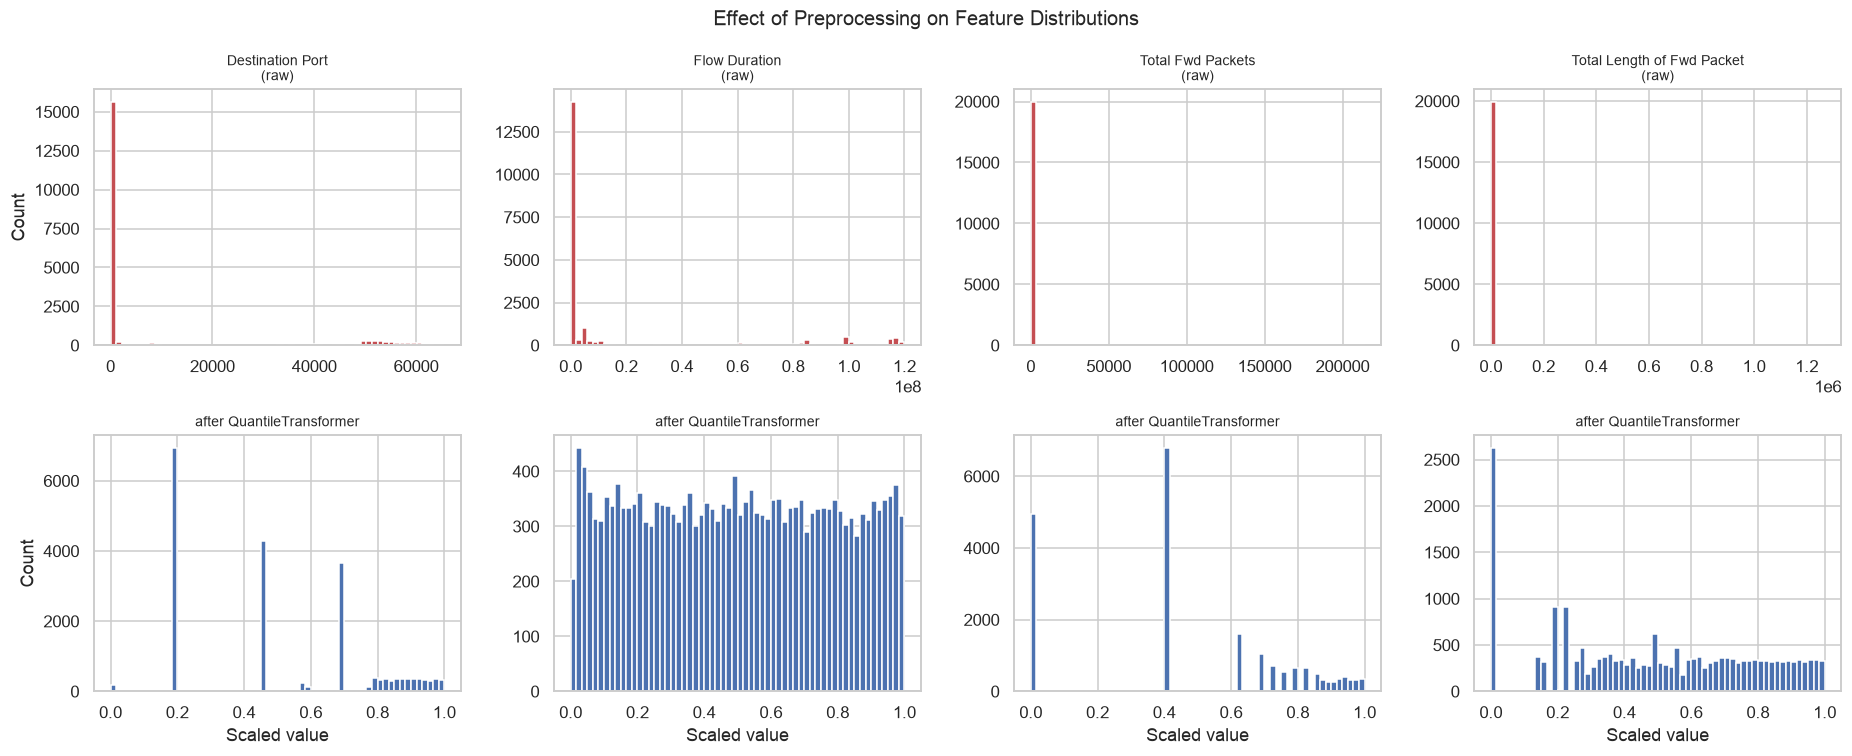

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))

# Plotting a sample keeps rendering fast; the shape is identical at full size.
# Local seeded generator, independent of the global NumPy state.
plot_sample = np.random.default_rng(RANDOM_STATE).choice(len(X_train_tree), size=20_000, replace=False)

for column in range(4):
    axes[0, column].hist(X_train_tree[plot_sample, column], bins=60, color="#C44E52")
    axes[0, column].set_title(f"{FEATURE_NAMES[column][:26]}\n(raw)", fontsize=9)
    axes[0, column].set_ylabel("Count" if column == 0 else "")

    axes[1, column].hist(X_train_scaled[plot_sample, column], bins=60, color="#4C72B0")
    axes[1, column].set_title("after QuantileTransformer", fontsize=9)
    axes[1, column].set_xlabel("Scaled value")
    axes[1, column].set_ylabel("Count" if column == 0 else "")

plt.suptitle("Effect of Preprocessing on Feature Distributions", fontsize=13)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure02_preprocessing_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

---
# Section D — Evaluation Framework

A single scoring function is used for all three models so the comparison is like-for-like. Each model produces a **continuous score** — a probability for the supervised models, a reconstruction error for the Autoencoder — which the threshold converts into a decision.

| Term | Meaning |
|---|---|
| TP | Attack correctly detected |
| FN | Attack missed |
| FP | Benign flow wrongly flagged |
| TN | Benign flow correctly ignored |

`find_best_f1_threshold` is called on the **validation** set only.

In [22]:
def evaluate_model(name, y_true, y_score, threshold=0.5, verbose=True):
    """Score a model's continuous predictions at a given decision threshold.

    Args:
        name: model name, used for display and in the results table.
        y_true: ground-truth binary labels (0 = benign, 1 = attack).
        y_score: continuous scores — probability or reconstruction error.
        threshold: scores at or above this value are classified as attacks.
        verbose: whether to print a formatted report.

    Returns:
        Dict of metrics and raw confusion-matrix counts.
    """
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results = {
        "Model": name,
        "Threshold": round(float(threshold), 6),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        # AP and ROC-AUC are computed from the continuous scores, so they
        # measure ranking quality independently of the chosen threshold.
        "AP": average_precision_score(y_true, y_score),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "FPR": fp / (fp + tn) if (fp + tn) else 0.0,
        "FNR": fn / (fn + tp) if (fn + tp) else 0.0,
        "Accuracy": accuracy_score(y_true, y_pred),
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn),
    }

    if verbose:
        print(f"\n{'=' * 58}")
        print(f"{name}  (threshold = {threshold:.6f})")
        print("=" * 58)
        for metric in ["Precision", "Recall", "F1", "AP", "ROC-AUC", "FPR", "FNR"]:
            print(f"  {metric:<12}: {results[metric]:.6f}")
        print(f"  {'Accuracy':<12}: {results['Accuracy']:.6f}  (reference only)")
        print(f"\n  Attacks detected : {tp:,} of {tp + fn:,}")
        print(f"  Attacks missed   : {fn:,}")
        print(f"  False alarms     : {fp:,} of {fp + tn:,} benign flows")

    return results

def find_best_f1_threshold(y_true, y_score):
    """Find the threshold maximising F1 across all achievable operating points.

    Must be called on the validation set only — calling it on the test set
    would make the reported test score optimistically biased.

    Args:
        y_true: ground-truth binary labels.
        y_score: continuous model scores.

    Returns:
        Tuple of (best threshold, F1 achieved at that threshold).
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    # Guard against division by zero where precision and recall are both 0.
    f1_scores = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    # thresholds is one element shorter than precision/recall by construction.
    best_index = int(np.nanargmax(f1_scores[:-1]))
    return float(thresholds[best_index]), float(f1_scores[best_index])

print("Evaluation framework ready.")

Evaluation framework ready.


---
# Section E — Model Development

## E.1 Model 1 — Logistic Regression (weighted)

Baseline. Fits one coefficient per feature, sums them, and passes the result through a sigmoid. Its limitation is structural: it can only draw a linear decision boundary, so a performance gap may reflect nonlinearity as well as model capacity, preprocessing and tuning.

| Parameter | Value | Reason |
|---|---|---|
| `class_weight` | `'balanced'` | Weights classes inversely to frequency; without it the model drifts toward the majority class |
| `max_iter` | 1000 | The default of 100 does not converge at this data size |
| `solver` | `'lbfgs'` | Standard choice for dense numeric data |

Trained on **Track 2** (scaled), since the model is scale-sensitive.

In [23]:
# Development diagnostics use validation; test is reserved for final reporting.
start_time = time.time()

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
logistic_model.fit(X_train_scaled, y_train)

logistic_train_time = time.time() - start_time

# predict_proba returns [P(benign), P(attack)]; column 1 is the attack probability.
logistic_val_scores = logistic_model.predict_proba(X_val_scaled)[:, 1]
logistic_test_scores = logistic_model.predict_proba(X_test_scaled)[:, 1]

print(f"Training time : {logistic_train_time:.1f}s")
print(f"Converged in  : {logistic_model.n_iter_[0]} iterations")

if logistic_model.n_iter_[0] >= 1000:
    print("WARNING — iteration limit reached; the model may not have fully converged.")

_ = evaluate_model(
    "Logistic Regression (validation, default threshold)", y_val, logistic_val_scores, 0.5
)

Training time : 5.7s
Converged in  : 220 iterations

Logistic Regression (validation, default threshold)  (threshold = 0.500000)
  Precision   : 0.875676
  Recall      : 0.982196
  F1          : 0.925882
  AP          : 0.931804
  ROC-AUC     : 0.993123
  FPR         : 0.028290
  FNR         : 0.017804
  Accuracy    : 0.973478  (reference only)

  Attacks detected : 83,522 of 85,036
  Attacks missed   : 1,514
  False alarms     : 11,858 of 419,157 benign flows


### E.1.1 Coefficient interpretation

Positive coefficients push a flow toward "attack", negative toward "benign". Worth comparing against LightGBM's feature importances in E.2.1.

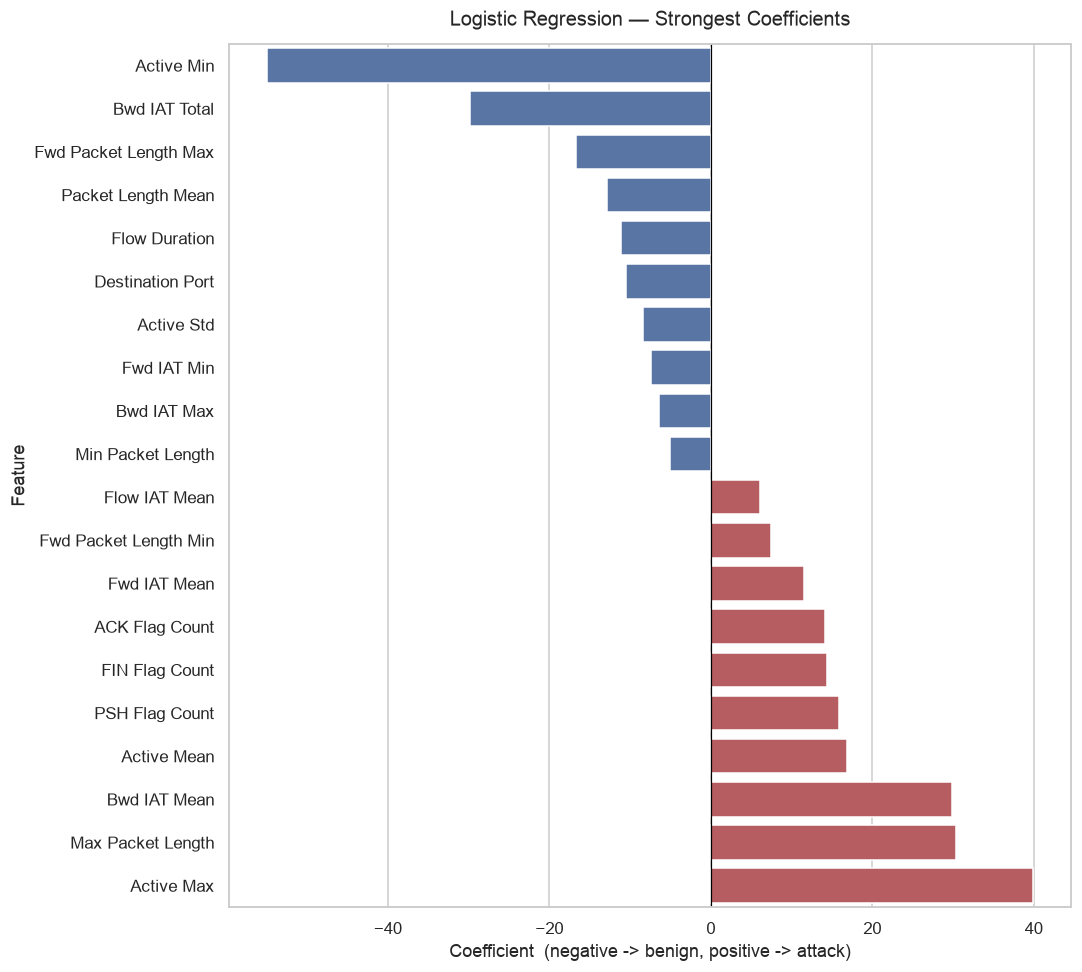

Strongest indicators of attack traffic:
Active Max               39.918064
Max Packet Length        30.314220
Bwd IAT Mean             29.837185
Active Mean              16.812313
PSH Flag Count           15.881637
FIN Flag Count           14.352995
ACK Flag Count           14.093550
Fwd IAT Mean             11.549646
Fwd Packet Length Min     7.444367
Flow IAT Mean             6.152968
dtype: float32


In [24]:
coefficients = pd.Series(logistic_model.coef_[0], index=FEATURE_NAMES).sort_values()

strongest_benign = coefficients.head(10)   # most negative
strongest_attack = coefficients.tail(10)   # most positive
plot_data = pd.concat([strongest_benign, strongest_attack])

plt.figure(figsize=(10, 9))
bar_colors = ["#4C72B0" if value < 0 else "#C44E52" for value in plot_data.values]
sns.barplot(x=plot_data.values, y=plot_data.index, hue=plot_data.index, palette=bar_colors, legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient  (negative -> benign, positive -> attack)")
plt.ylabel("Feature")
plt.title("Logistic Regression — Strongest Coefficients", fontsize=13, pad=12)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure03_logistic_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

print("Strongest indicators of attack traffic:")
print(strongest_attack.sort_values(ascending=False))

## E.2 Model 2 — LightGBM

Gradient boosting: hundreds of trees built in sequence, each trained on the errors of its predecessors.

| Parameter | Value | Reason |
|---|---|---|
| `scale_pos_weight` | benign/attack ratio | LightGBM's class weighting equivalent |
| `n_estimators` + early stopping | 1000, patience 50 | The model chooses its own size using validation data |
| `eval_metric` | `'average_precision'` | Early stopping monitors **AP**, not accuracy |
| `subsample`, `colsample_bytree` | 0.8 | Decorrelates the trees |
| `reg_alpha`, `reg_lambda` | 0.1 | L1 and L2 regularisation |

In [25]:
# Early stopping monitors average precision only.
# Ratio of benign to attack flows in the training set only.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

start_time = time.time()

lightgbm_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

lightgbm_model.fit(
    X_train_tree,
    y_train,
    eval_set=[(X_val_tree, y_val)],
    eval_metric="average_precision",
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True, verbose=False),
        lgb.log_evaluation(100),
    ],
)

lightgbm_train_time = time.time() - start_time

lightgbm_val_scores = lightgbm_model.predict_proba(X_val_tree)[:, 1]
lightgbm_test_scores = lightgbm_model.predict_proba(X_test_tree)[:, 1]

print(f"\nTraining time : {lightgbm_train_time:.1f}s")
print(f"Trees used    : {lightgbm_model.best_iteration_} of 1000 (chosen by early stopping)")

_ = evaluate_model("LightGBM (validation, default threshold)", y_val, lightgbm_val_scores, 0.5)

scale_pos_weight = 4.93


/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's average_precision: 0.999847	valid_0's binary_logloss: 0.00483952
[200]	valid_0's average_precision: 0.999948	valid_0's binary_logloss: 0.00214767
[300]	valid_0's average_precision: 0.999952	valid_0's binary_logloss: 0.00200507

Training time : 16.4s
Trees used    : 320 of 1000 (chosen by early stopping)

LightGBM (validation, default threshold)  (threshold = 0.500000)
  Precision   : 0.997091
  Recall      : 0.999624
  F1          : 0.998356
  AP          : 0.999952
  ROC-AUC     : 0.999990
  FPR         : 0.000592
  FNR         : 0.000376
  Accuracy    : 0.999445  (reference only)

  Attacks detected : 85,004 of 85,036
  Attacks missed   : 32
  False alarms     : 248 of 419,157 benign flows


*Output: the tree count reported is the number early stopping selected, not the 1000 permitted.*

### E.2.1 Feature importance

Counts how often each feature was chosen as a split point across all trees.

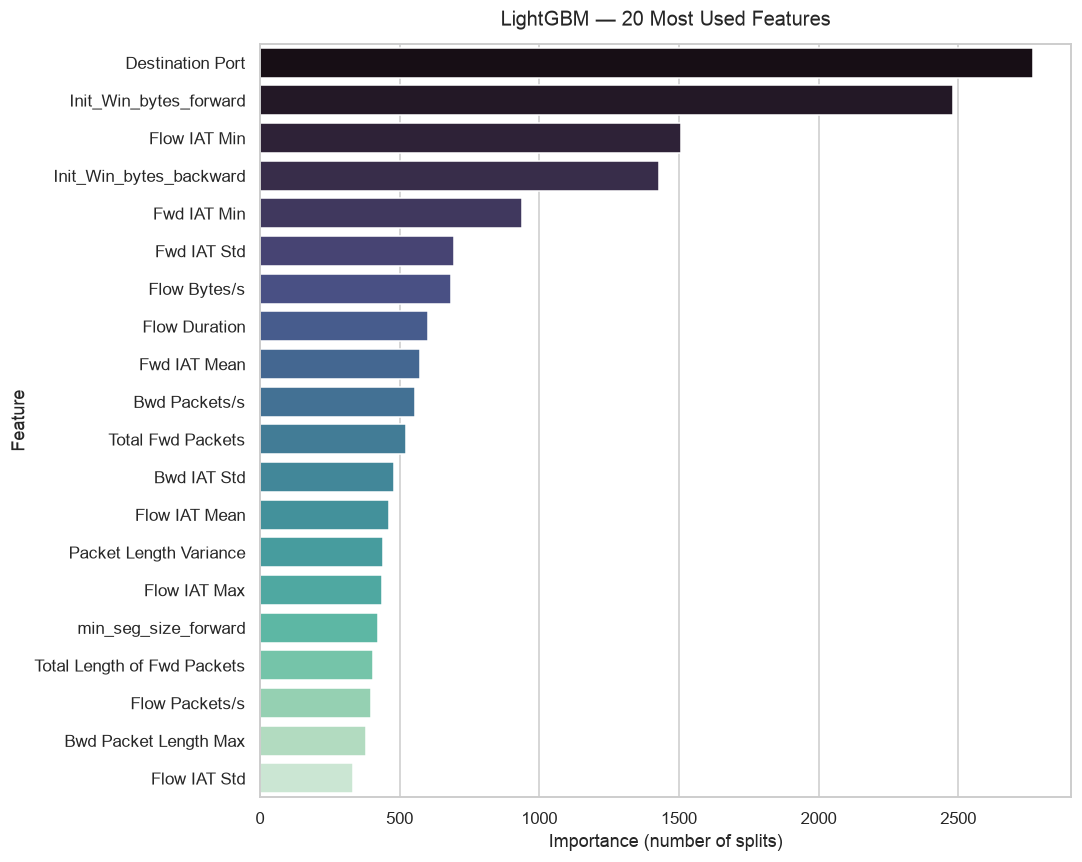

Destination Port               2767
Init_Win_bytes_forward         2483
Flow IAT Min                   1508
Init_Win_bytes_backward        1430
Fwd IAT Min                     937
Fwd IAT Std                     695
Flow Bytes/s                    683
Flow Duration                   602
Fwd IAT Mean                    574
Bwd Packets/s                   556
Total Fwd Packets               523
Bwd IAT Std                     479
Flow IAT Mean                   462
Packet Length Variance          442
Flow IAT Max                    437
min_seg_size_forward            423
Total Length of Fwd Packets     404
Flow Packets/s                  398
Bwd Packet Length Max           381
Flow IAT Std                    332
dtype: int32


In [26]:
importances = pd.Series(lightgbm_model.feature_importances_, index=FEATURE_NAMES)
top_importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_importances.values, y=top_importances.index, hue=top_importances.index, palette="mako", legend=False)
plt.xlabel("Importance (number of splits)")
plt.ylabel("Feature")
plt.title("LightGBM — 20 Most Used Features", fontsize=13, pad=12)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure04_lightgbm_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print(top_importances)

## E.3 Model 3 — Autoencoder

An hourglass network: the encoder compresses each flow to a 16-value bottleneck, the decoder rebuilds it. Network weights are trained on **benign traffic only**. Shared preprocessing uses all training rows, and architecture/threshold selection uses labelled validation data. Flows it cannot reconstruct produce high error, and that error is the anomaly score.

| Choice | Reason |
|---|---|
| Bottleneck 16 | Forces real compression; too wide and the network copies inputs through unchanged |
| `BatchNormalization` | Stabilises training |
| `Dropout(0.1)` | Discourages memorisation |
| `sigmoid` output | Matches the [0, 1] range of the quantile-transformed inputs |

In [27]:
# Seed Python, NumPy and TensorFlow and request deterministic ops.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

print(f"TensorFlow version : {tf.__version__}")
gpu_available = bool(tf.config.list_physical_devices("GPU"))
print(f"GPU available      : {gpu_available}")

if not gpu_available:
    print("\nTraining will use the CPU. Record runtime and peak memory for your environment.")

TensorFlow version : 2.21.0
GPU available      : False

Training will use the CPU. Record runtime and peak memory for your environment.


In [28]:
# The defining step: training data contains benign flows only.
X_train_benign = X_train_scaled[y_train.values == 0]

print(f"Benign flows used for training : {X_train_benign.shape[0]:,}")
print(f"Attack flows excluded          : {(y_train == 1).sum():,}")

input_dim = X_train_benign.shape[1]

autoencoder = keras.Sequential(
    [
        layers.Input(shape=(input_dim,)),
        # Encoder
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(32, activation="relu"),
        layers.Dense(BOTTLENECK_SIZE, activation="relu", name="bottleneck"),
        # Decoder
        layers.Dense(32, activation="relu"),
        layers.Dense(64, activation="relu"),
        # sigmoid matches the [0, 1] range of the quantile-transformed inputs
        layers.Dense(input_dim, activation="sigmoid"),
    ],
    name="autoencoder",
)

autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
autoencoder.summary()

Benign flows used for training : 1,257,471
Attack flows excluded          : 255,108


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 44)             │         2,860 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,260 (43.98 KB)

 Trainable params: 11,132 (43.48 KB)

 Non-trainable params: 128 (512.00 B)

In [29]:
start_time = time.time()

training_history = autoencoder.fit(
    X_train_benign,
    X_train_benign,  # input and target are identical — this is the autoencoder objective
    epochs=AE_EPOCHS,
    batch_size=AE_BATCH_SIZE,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3
        ),
    ],
    # One line per epoch.
    verbose=2,
)

autoencoder_train_time = time.time() - start_time
print(f"\nTraining time: {autoencoder_train_time:.1f}s")

Epoch 1/30


E0000 00:00:1790546447.370533  575793 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


2211/2211 - 3s - 1ms/step - loss: 0.0076 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 2/30
2211/2211 - 2s - 952us/step - loss: 0.0021 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 3/30
2211/2211 - 2s - 948us/step - loss: 0.0017 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 4/30
2211/2211 - 2s - 976us/step - loss: 0.0015 - val_loss: 9.4385e-04 - learning_rate: 0.0010
Epoch 5/30
2211/2211 - 2s - 951us/step - loss: 0.0014 - val_loss: 8.3619e-04 - learning_rate: 0.0010
Epoch 6/30
2211/2211 - 2s - 950us/step - loss: 0.0013 - val_loss: 8.2133e-04 - learning_rate: 0.0010
Epoch 7/30
2211/2211 - 2s - 961us/step - loss: 0.0012 - val_loss: 7.3889e-04 - learning_rate: 0.0010
Epoch 8/30
2211/2211 - 2s - 949us/step - loss: 0.0012 - val_loss: 6.9669e-04 - learning_rate: 0.0010
Epoch 9/30
2211/2211 - 2s - 949us/step - loss: 0.0011 - val_loss: 6.6414e-04 - learning_rate: 0.0010
Epoch 10/30
2211/2211 - 2s - 963us/step - loss: 0.0011 - val_loss: 6.5201e-04 - learning_rate: 0.0010
Epoch 11/30
22

Both curves should fall and flatten together. Validation loss sitting *below* training loss is expected here: `Dropout` is active during training but disabled during evaluation.

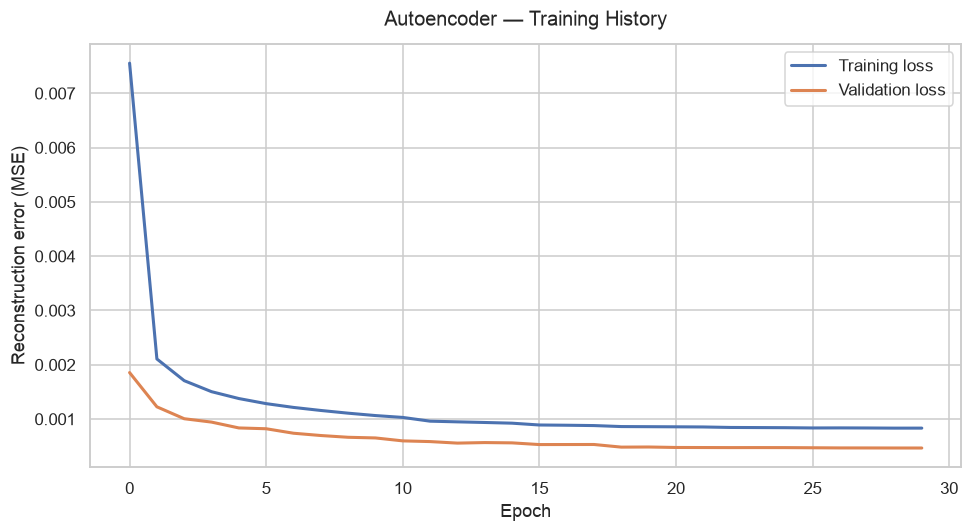

In [30]:
plt.figure(figsize=(9, 5))
plt.plot(training_history.history["loss"], label="Training loss", linewidth=2)
plt.plot(training_history.history["val_loss"], label="Validation loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction error (MSE)")
plt.title("Autoencoder — Training History", fontsize=13, pad=12)
plt.legend()
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure05_autoencoder_training_history.png", dpi=300, bbox_inches="tight")
plt.show()

### E.3.1 Does reconstruction error separate the classes?

If the method works, attack flows should show visibly higher error and the two distributions should sit apart. Overlap indicates attacks that look statistically ordinary at the flow level.

In [31]:
# Development diagnostics use validation reconstruction errors.
def compute_reconstruction_error(model, X, batch_size=4096):
    """Compute per-row reconstruction error, used as the anomaly score.

    Args:
        model: trained autoencoder.
        X: scaled feature matrix.
        batch_size: prediction batch size.

    Returns:
        1-D array of mean squared reconstruction error per row. Higher values
        indicate flows the model could not reconstruct, i.e. likely anomalies.
    """
    reconstructed = model.predict(X, batch_size=batch_size, verbose=0)
    return np.mean(np.square(X - reconstructed), axis=1)

autoencoder_val_scores = compute_reconstruction_error(autoencoder, X_val_scaled)
autoencoder_test_scores = compute_reconstruction_error(autoencoder, X_test_scaled)

benign_error = autoencoder_val_scores[y_val.values == 0]
attack_error = autoencoder_val_scores[y_val.values == 1]
separation_ratio = attack_error.mean() / benign_error.mean()

print(f"Mean reconstruction error — benign : {benign_error.mean():.6f}")
print(f"Mean reconstruction error — attack : {attack_error.mean():.6f}")
print(f"Separation ratio                   : {separation_ratio:.2f}x")

E0000 00:00:1790546514.066426  575793 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Mean reconstruction error — benign : 0.000464
Mean reconstruction error — attack : 0.009814
Separation ratio                   : 21.17x


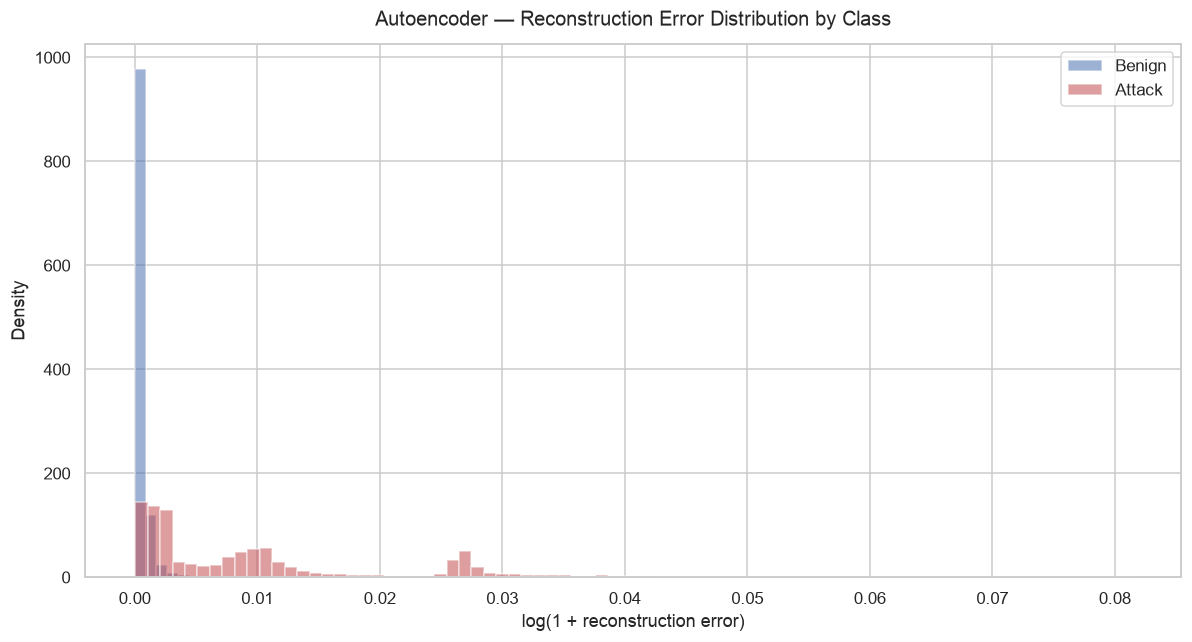

In [32]:
plt.figure(figsize=(11, 6))

for class_value, color, label in [(0, "#4C72B0", "Benign"), (1, "#C44E52", "Attack")]:
    class_errors = autoencoder_val_scores[y_val.values == class_value]
    # log1p is a mild transform near zero; this is not a logarithmic axis.
    plt.hist(
        np.log1p(class_errors),
        bins=80,
        alpha=0.55,
        label=label,
        color=color,
        density=True,
    )

plt.xlabel("log(1 + reconstruction error)")
plt.ylabel("Density")
plt.title(
    "Autoencoder — Reconstruction Error Distribution by Class", fontsize=13, pad=12
)
plt.legend()
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure06_validation_reconstruction_errors.png", dpi=300, bbox_inches="tight")
plt.show()

*Output: the separation ratio is the mean attack error divided by the mean benign error. This ratio alone does not measure distribution overlap or detection quality.*

### E.3.2 A benign-validation percentile threshold

Uses **no attack labels** — only the error distribution of benign validation traffic. The 95th percentile accepts roughly a 5% false alarm rate by construction. This is how the model would be deployed where no labelled attacks exist.

Because the percentile is computed on the same benign validation rows it is evaluated on here, the 5% FPR below holds **by construction** and is not an estimate. The held-out estimate for this operating point is reported on the test set in Section G.1a.

In [33]:
# Evaluated on the benign validation rows used for calibration (FPR = 5% by construction).
unsupervised_threshold = float(
    np.percentile(autoencoder_val_scores[y_val.values == 0], 95)
)

print(f"95th-percentile threshold: {unsupervised_threshold:.6f}")

unsupervised_result = evaluate_model(
    "Autoencoder (benign P95 threshold, calibration set)",
    y_val,
    autoencoder_val_scores,
    unsupervised_threshold,
)

95th-percentile threshold: 0.001544

Autoencoder (benign P95 threshold, calibration set)  (threshold = 0.001544)
  Precision   : 0.762173
  Recall      : 0.789842
  F1          : 0.775761
  AP          : 0.852079
  ROC-AUC     : 0.949998
  FPR         : 0.050000
  FNR         : 0.210158
  Accuracy    : 0.922988  (reference only)

  Attacks detected : 67,165 of 85,036
  Attacks missed   : 17,871
  False alarms     : 20,958 of 419,157 benign flows


### E.3.3 Optional exploratory bottleneck comparison

The bottleneck width controls how much the network is forced to compress. Too narrow and it cannot reconstruct benign traffic well; too wide and it learns to pass inputs through unchanged, reconstructing attacks just as accurately and defeating the method.

The initial value of 16 was a starting assumption, so this cell compares several widths. Each candidate is trained for fewer epochs, providing only a preliminary comparison, and evaluated on the **validation** set — selecting on test results would bias the reported performance.

In [34]:
def build_autoencoder(input_dim, bottleneck_size, seed=RANDOM_STATE):
    """Build and compile an autoencoder with a given bottleneck width.

    Args:
        input_dim: number of input features.
        bottleneck_size: width of the compressed representation.
        seed: random seed for reproducible weight initialisation.

    Returns:
        Compiled Keras model.
    """
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Dense(32, activation="relu"),
        layers.Dense(bottleneck_size, activation="relu", name="bottleneck"),
        layers.Dense(32, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(input_dim, activation="sigmoid"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

# Exploratory only: the primary model retains the predeclared width 16.
# A future architecture selection requires repeated seeds and comparable training budgets.
# Compare bottleneck widths on the VALIDATION set, never on test.
bottleneck_results = []

for size in [8, 16, 24, 32]:
    candidate = build_autoencoder(input_dim, size)
    candidate.fit(
        X_train_benign, X_train_benign,
        epochs=15,                 # shorter runs are sufficient for comparison
        batch_size=AE_BATCH_SIZE,
        validation_split=0.1,
        verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True)],
    )
    scores = compute_reconstruction_error(candidate, X_val_scaled)
    bottleneck_results.append({
        "Bottleneck size": size,
        "Validation AP": round(average_precision_score(y_val, scores), 4),
    })

pd.DataFrame(bottleneck_results)

E0000 00:00:1790546553.319985  575793 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
E0000 00:00:1790546589.720512  575793 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

,Bottleneck size,Validation AP
0,8,0.9013
1,16,0.8498
2,24,0.8657
3,32,0.8381


*This exploratory table does not change the primary model. A single short run per width is insufficient to establish a robust winner; any future selection must occur on validation before new final test evaluation.*

---
# Section F — Threshold Optimisation

The default 0.5 is a conventional operating point; the appropriate threshold depends on calibration and the desired trade-off. Lowering the threshold raises recall and lowers precision; raising it does the reverse. Tuned on **validation**, never on test.

In [35]:
model_scores = {
    "Logistic Regression": (logistic_val_scores, logistic_test_scores),
    "LightGBM": (lightgbm_val_scores, lightgbm_test_scores),
    "Autoencoder": (autoencoder_val_scores, autoencoder_test_scores),
}

thresholds = {}
for model_name, (val_scores, _) in model_scores.items():
    threshold, val_f1 = find_best_f1_threshold(y_val, val_scores)
    thresholds[model_name] = threshold
    print(f"{model_name:<22} threshold = {threshold:.6f}   (validation F1 = {val_f1:.6f})")
# Select the model before final test reporting; AP is the sole selection criterion.
validation_comparison = pd.DataFrame([
    evaluate_model(name, y_val, val_scores, thresholds[name], verbose=False)
    for name, (val_scores, _) in model_scores.items()
])
best_model_name = validation_comparison.loc[validation_comparison["AP"].idxmax(), "Model"]
print("Model selected on validation AP:", best_model_name)

Logistic Regression    threshold = 0.713471   (validation F1 = 0.945196)
LightGBM               threshold = 0.846680   (validation F1 = 0.998560)
Autoencoder            threshold = 0.001953   (validation F1 = 0.782157)
Model selected on validation AP: LightGBM


## F.1 Precision-Recall curves

Each curve traces precision and recall across all thresholds; AP summarises precision weighted by recall increments; it is not trapezoidal curve area. The dashed line is the no-skill baseline, sitting at the attack rate.

**AP rather than ROC-AUC:** ROC-AUC can obscure operational false-alarm counts when benign traffic is abundant; report AP and false alarms alongside it.

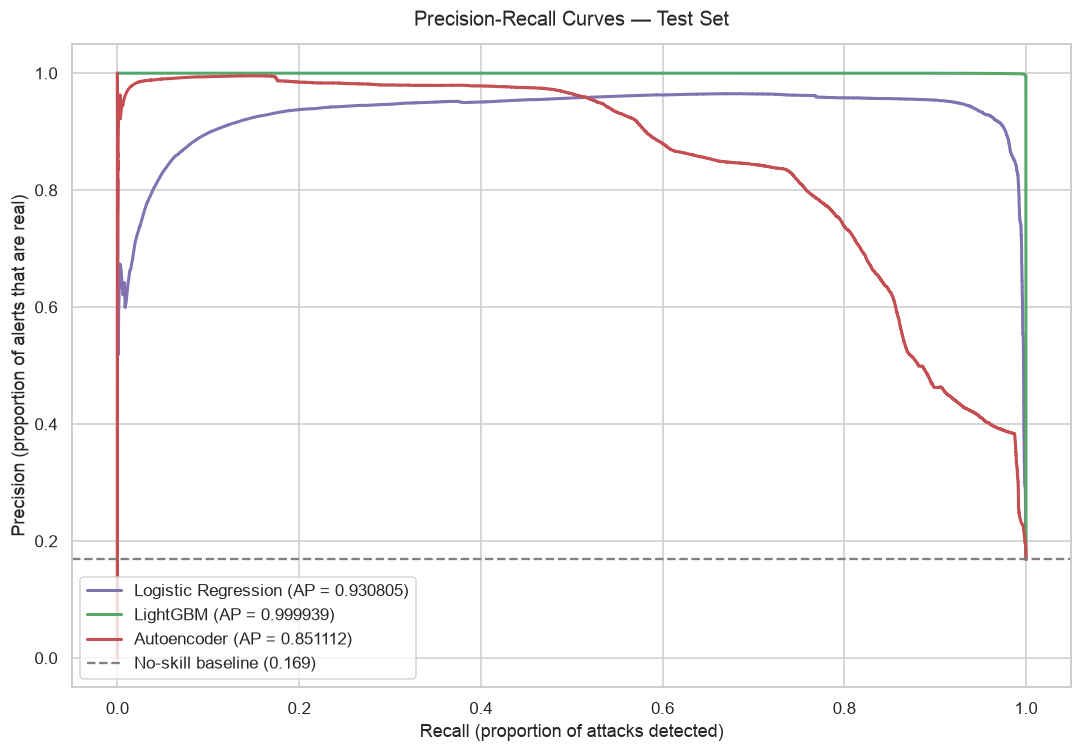

In [36]:
plt.figure(figsize=(10, 7))

curve_colors = {
    "Logistic Regression": "#8172B2",
    "LightGBM": "#55A868",
    "Autoencoder": "#C44E52",
}

for model_name, (_, test_scores) in model_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, test_scores)
    pr_auc = average_precision_score(y_test, test_scores)
    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {pr_auc:.6f})",
        linewidth=2,
        color=curve_colors[model_name],
    )

plt.axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    label=f"No-skill baseline ({y_test.mean():.3f})",
)

plt.xlabel("Recall (proportion of attacks detected)")
plt.ylabel("Precision (proportion of alerts that are real)")
plt.title("Precision-Recall Curves — Test Set", fontsize=13, pad=12)
plt.legend(loc="lower left")
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure07_test_precision_recall.png", dpi=300, bbox_inches="tight")
plt.show()

## F.2 The operational trade-off

Translates the threshold into concrete consequences: attacks slipping through versus false alarms to review.

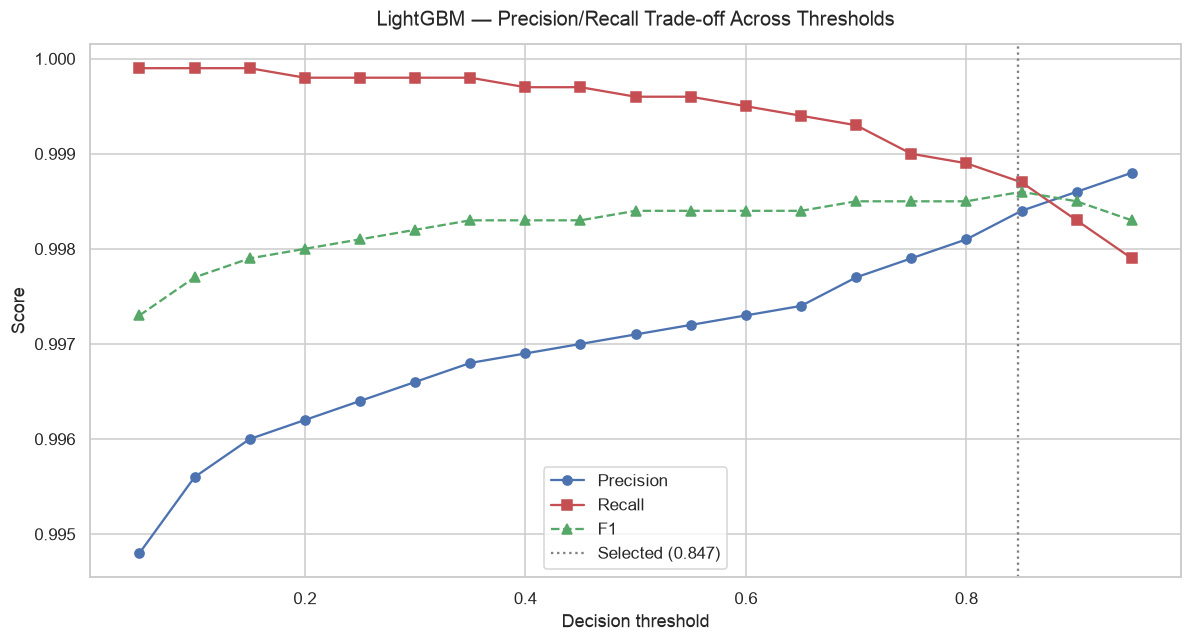

,Threshold,Precision,Recall,F1,False alarms,Missed attacks
0,0.05,0.9948,0.9999,0.9973,446,8
1,0.10,0.9956,0.9999,0.9977,378,9
2,0.15,0.9960,0.9999,0.9979,345,12
3,0.20,0.9962,0.9998,0.9980,328,13
4,0.25,0.9964,0.9998,0.9981,307,13
5,0.30,0.9966,0.9998,0.9982,287,14
6,0.35,0.9968,0.9998,0.9983,275,17
7,0.40,0.9969,0.9997,0.9983,268,22
8,0.45,0.9970,0.9997,0.9983,258,29
9,0.50,0.9971,0.9996,0.9984,248,32


In [37]:
# Threshold sweep on validation, not test.
sweep_rows = []

for candidate_threshold in np.linspace(0.05, 0.95, 19):
    predictions = (lightgbm_val_scores >= candidate_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, predictions).ravel()
    sweep_rows.append(
        {
            "Threshold": round(candidate_threshold, 2),
            "Precision": round(precision_score(y_val, predictions, zero_division=0), 4),
            "Recall": round(recall_score(y_val, predictions, zero_division=0), 4),
            "F1": round(f1_score(y_val, predictions, zero_division=0), 4),
            "False alarms": int(fp),
            "Missed attacks": int(fn),
        }
    )

threshold_sweep = pd.DataFrame(sweep_rows)

plt.figure(figsize=(11, 6))
plt.plot(threshold_sweep["Threshold"], threshold_sweep["Precision"],
         marker="o", label="Precision", color="#4C72B0")
plt.plot(threshold_sweep["Threshold"], threshold_sweep["Recall"],
         marker="s", label="Recall", color="#C44E52")
plt.plot(threshold_sweep["Threshold"], threshold_sweep["F1"],
         marker="^", label="F1", color="#55A868", linestyle="--")
plt.axvline(thresholds["LightGBM"], color="gray", linestyle=":",
            label=f"Selected ({thresholds['LightGBM']:.3f})")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("LightGBM — Precision/Recall Trade-off Across Thresholds", fontsize=13, pad=12)
plt.legend()
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure08_validation_threshold_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

threshold_sweep

*Output: note how flat F1 is across the range compared with the swing in missed attacks and false alarms.*

## F.3 A second operating point: prioritising recall

F1 balances precision and recall but does not specify an explicit cost ratio between missed intrusions and false alarms. F-beta with **beta = 2** weights recall four times as heavily, which better matches a security context.

Both operating points are reported.

In [38]:
from sklearn.metrics import fbeta_score

# beta > 1 weights recall above precision; beta = 2 gives recall 4x the weight.
RECALL_WEIGHT_BETA = 2

def find_best_fbeta_threshold(y_true, y_score, beta=RECALL_WEIGHT_BETA):
    """Find the threshold maximising F-beta on the given set.

    Args:
        y_true: ground-truth binary labels.
        y_score: continuous model scores.
        beta: recall weighting. Values above 1 prioritise recall.

    Returns:
        Tuple of (best threshold, F-beta score at that threshold).
    """
    precision, recall, thresholds_array = precision_recall_curve(y_true, y_score)
    beta_squared = beta ** 2
    fbeta = (
        (1 + beta_squared) * precision * recall
        / np.maximum(beta_squared * precision + recall, 1e-12)
    )
    best_index = int(np.nanargmax(fbeta[:-1]))
    return float(thresholds_array[best_index]), float(fbeta[best_index])

recall_oriented_threshold, validation_fbeta = find_best_fbeta_threshold(
    y_val, lightgbm_val_scores
)

print(f"F1-optimal threshold : {thresholds['LightGBM']:.6f}")
print(f"F2-optimal threshold : {recall_oriented_threshold:.6f}")
print(f"Validation F2 score  : {validation_fbeta:.6f}")

F1-optimal threshold : 0.846680
F2-optimal threshold : 0.328840
Validation F2 score  : 0.999210


In [39]:
# Compare both operating points on the test set.
balanced_point = evaluate_model(
    "Balanced (F1)", y_test, lightgbm_test_scores,
    thresholds["LightGBM"], verbose=False,
)
recall_point = evaluate_model(
    "Recall-oriented (F2)", y_test, lightgbm_test_scores,
    recall_oriented_threshold, verbose=False,
)

operating_points = pd.DataFrame([balanced_point, recall_point])[
    ["Model", "Threshold", "Precision", "Recall", "FN", "FP"]
]
operating_points.columns = [
    "Operating point", "Threshold", "Precision", "Recall",
    "Attacks missed", "False alarms",
]

extra_alarms = recall_point["FP"] - balanced_point["FP"]
attacks_saved = balanced_point["FN"] - recall_point["FN"]

print(
    f"Moving to the recall-oriented threshold detects {attacks_saved:,} "
    f"additional attacks at the cost of {extra_alarms:,} additional false alarms.\n"
)
operating_points

Moving to the recall-oriented threshold detects 121 additional attacks at the cost of 176 additional false alarms.



,Operating point,Threshold,Precision,Recall,Attacks missed,False alarms
0,Balanced (F1),0.84668,0.998060,0.998318,143,165
1,Recall-oriented (F2),0.32884,0.996005,0.999741,22,341


---
# Section G — Model Comparison

All three models on the untouched test set, each at its own tuned threshold.

In [40]:
results = [
    evaluate_model(model_name, y_test, test_scores, thresholds[model_name])
    for model_name, (_, test_scores) in model_scores.items()
]

comparison = pd.DataFrame(results)
comparison["Train time (s)"] = [
    round(logistic_train_time, 1),
    round(lightgbm_train_time, 1),
    round(autoencoder_train_time, 1),
]

comparison_table = comparison[
    ["Model", "Threshold", "Precision", "Recall", "F1",
     "AP", "ROC-AUC", "FPR", "FNR", "Train time (s)"]
].round(6)

comparison_table


Logistic Regression  (threshold = 0.713471)
  Precision   : 0.925631
  Recall      : 0.962075
  F1          : 0.943501
  AP          : 0.930805
  ROC-AUC     : 0.992836
  FPR         : 0.015681
  FNR         : 0.037925
  Accuracy    : 0.980567  (reference only)

  Attacks detected : 81,811 of 85,036
  Attacks missed   : 3,225
  False alarms     : 6,573 of 419,158 benign flows

LightGBM  (threshold = 0.846680)
  Precision   : 0.998060
  Recall      : 0.998318
  F1          : 0.998189
  AP          : 0.999939
  ROC-AUC     : 0.999982
  FPR         : 0.000394
  FNR         : 0.001682
  Accuracy    : 0.999389  (reference only)

  Attacks detected : 84,893 of 85,036
  Attacks missed   : 143
  False alarms     : 165 of 419,158 benign flows

Autoencoder  (threshold = 0.001953)
  Precision   : 0.829073
  Recall      : 0.741404
  F1          : 0.782791
  AP          : 0.851112
  ROC-AUC     : 0.949784
  FPR         : 0.031010
  FNR         : 0.258596
  Accuracy    : 0.930606  (reference only)


,Model,Threshold,Precision,Recall,F1,AP,ROC-AUC,FPR,FNR,Train time (s)
0,Logistic Regression,0.713471,0.925631,0.962075,0.943501,0.930805,0.992836,0.015681,0.037925,5.7
1,LightGBM,0.846680,0.998060,0.998318,0.998189,0.999939,0.999982,0.000394,0.001682,16.4
2,Autoencoder,0.001953,0.829073,0.741404,0.782791,0.851112,0.949784,0.031010,0.258596,66.6


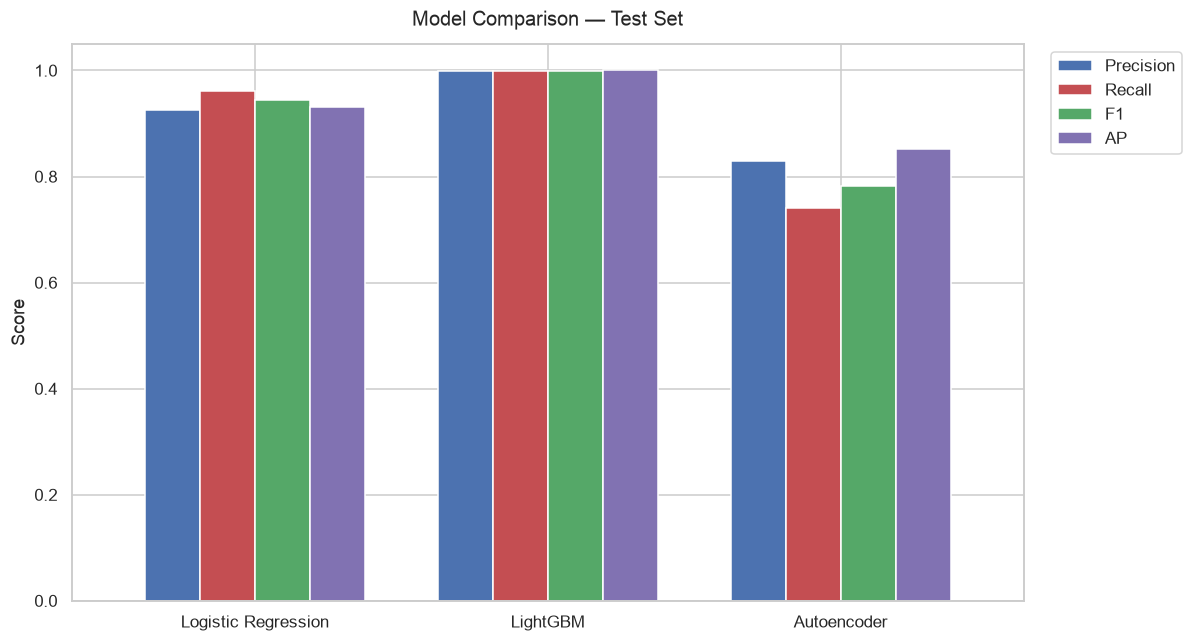

In [41]:
metrics_to_plot = ["Precision", "Recall", "F1", "AP"]

axis = comparison.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75,
    color=["#4C72B0", "#C44E52", "#55A868", "#8172B2"],
)
axis.set_ylabel("Score")
axis.set_xlabel("")
axis.set_ylim(0, 1.05)
axis.set_title("Model Comparison — Test Set", fontsize=13, pad=12)
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure09_test_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## G.1 Results in operational terms

The same results as raw counts rather than scores between 0 and 1.

In [42]:
operational = comparison[["Model", "TP", "FN", "FP", "TN"]].copy()
operational.columns = [
    "Model",
    "Attacks detected",
    "Attacks missed",
    "False alarms",
    "Benign correct",
]
operational["Detection rate"] = (
    operational["Attacks detected"]
    / (operational["Attacks detected"] + operational["Attacks missed"])
).map("{:.2%}".format)

operational

,Model,Attacks detected,Attacks missed,False alarms,Benign correct,Detection rate
0,Logistic Regression,81811,3225,6573,412585,96.21%
1,LightGBM,84893,143,165,418993,99.83%
2,Autoencoder,63046,21990,12998,406160,74.14%


### G.1a Label-free Autoencoder operating point on the test set

The 95th-percentile threshold from E.3.2 uses benign validation traffic only and no attack labels. Evaluating it here gives a held-out estimate of that operating point, next to the F1-tuned threshold above (which used validation attack labels).

In [43]:
# Held-out test evaluation of the label-free (benign P95) Autoencoder threshold.
autoencoder_label_free_test = evaluate_model(
    "Autoencoder (benign P95 threshold)", y_test, autoencoder_test_scores, unsupervised_threshold
)
autoencoder_operating_points = pd.DataFrame([
    comparison.loc[comparison["Model"] == "Autoencoder"].iloc[0].to_dict() | {"Model": "Autoencoder (validation F1 threshold)"},
    autoencoder_label_free_test,
])[["Model", "Threshold", "Precision", "Recall", "F1", "FPR", "TP", "FN", "FP"]]
autoencoder_operating_points


Autoencoder (benign P95 threshold)  (threshold = 0.001544)
  Precision   : 0.759713
  Recall      : 0.789195
  F1          : 0.774173
  AP          : 0.851112
  ROC-AUC     : 0.949784
  FPR         : 0.050640
  FNR         : 0.210805
  Accuracy    : 0.922347  (reference only)

  Attacks detected : 67,110 of 85,036
  Attacks missed   : 17,926
  False alarms     : 21,226 of 419,158 benign flows


,Model,Threshold,Precision,Recall,F1,FPR,TP,FN,FP
0,Autoencoder (validation F1 threshold),0.001953,0.829073,0.741404,0.782791,0.03101,63046,21990,12998
1,Autoencoder (benign P95 threshold),0.001544,0.759713,0.789195,0.774173,0.05064,67110,17926,21226


## G.2 Confusion matrices

Rows are the true class, columns the predicted class. The **bottom-left** cell holds real attacks predicted as benign — the intrusions that would have gone undetected.

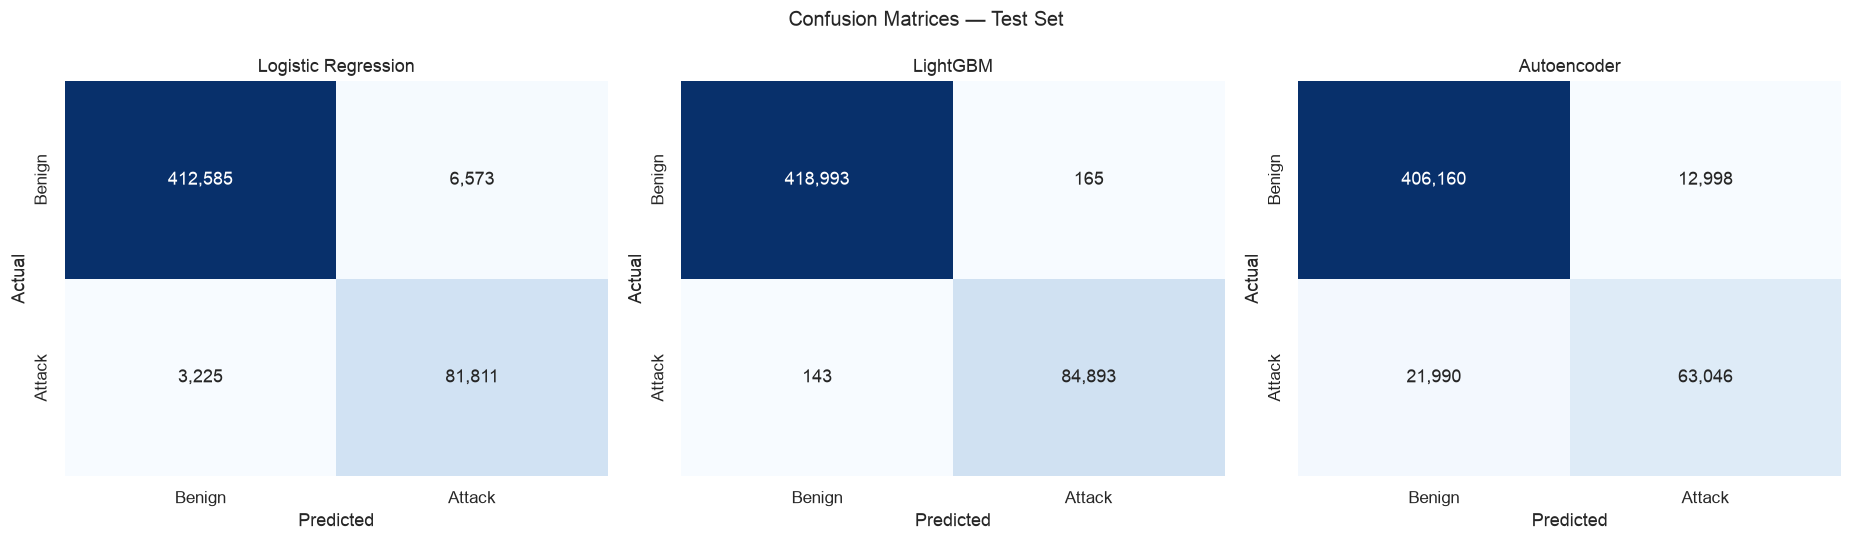

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for axis, (model_name, (_, test_scores)) in zip(axes, model_scores.items()):
    predictions = (test_scores >= thresholds[model_name]).astype(int)
    matrix = confusion_matrix(y_test, predictions)

    sns.heatmap(
        matrix,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        ax=axis,
        xticklabels=["Benign", "Attack"],
        yticklabels=["Benign", "Attack"],
    )
    axis.set_title(model_name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Test Set", fontsize=13)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure10_test_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

---
# Section H — Validity Checks

Three checks run before any conclusions are drawn: overfitting, data leakage, and metric suitability.

## H.1 Overfitting and underfitting check

| Pattern | Diagnosis |
|---|---|
| Train ≫ test | Overfitting |
| Train ≈ test, both low | Underfitting |
| Train ≈ test, both high | Healthy generalisation |

In [45]:
# Score the training set with each model for comparison against test performance.
logistic_train_scores = logistic_model.predict_proba(X_train_scaled)[:, 1]
lightgbm_train_scores = lightgbm_model.predict_proba(X_train_tree)[:, 1]
autoencoder_train_scores = compute_reconstruction_error(autoencoder, X_train_scaled)

train_score_map = {
    "Logistic Regression": logistic_train_scores,
    "LightGBM": lightgbm_train_scores,
    "Autoencoder": autoencoder_train_scores,
}

overfitting_rows = []
for model_name, (_, test_scores) in model_scores.items():
    train_pr_auc = average_precision_score(y_train, train_score_map[model_name])
    test_pr_auc = average_precision_score(y_test, test_scores)
    overfitting_rows.append(
        {
            "Model": model_name,
            "Train AP": round(train_pr_auc, 4),
            "Test AP": round(test_pr_auc, 4),
            "Gap": round(train_pr_auc - test_pr_auc, 4),
        }
    )

overfitting_check = pd.DataFrame(overfitting_rows)
print("A small gap is a within-split diagnostic; external generalisation remains untested.\n")
overfitting_check

E0000 00:00:1790546674.060606  575793 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


A small gap is a within-split diagnostic; external generalisation remains untested.



,Model,Train AP,Test AP,Gap
0,Logistic Regression,0.9303,0.9308,-0.0005
1,LightGBM,1.0000,0.9999,0.0000
2,Autoencoder,0.8501,0.8511,-0.0010


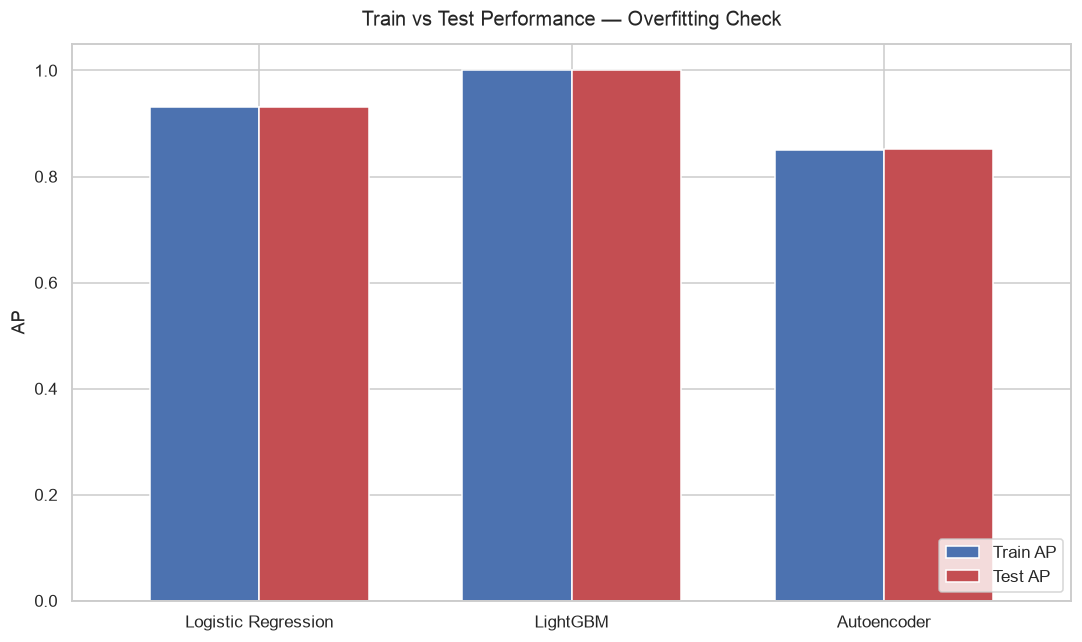

In [46]:
plot_frame = overfitting_check.set_index("Model")[["Train AP", "Test AP"]]

axis = plot_frame.plot(kind="bar", figsize=(10, 6), width=0.7,
                       color=["#4C72B0", "#C44E52"])
axis.set_ylabel("AP")
axis.set_xlabel("")
axis.set_ylim(0, 1.05)
axis.set_title("Train vs Test Performance — Overfitting Check", fontsize=13, pad=12)
axis.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure11_train_test_ap.png", dpi=300, bbox_inches="tight")
plt.show()

*A small train/test gap is a within-split diagnostic, not proof of generalisation to other capture periods or networks.*

## H.2 Data leakage check

Four safeguards were applied: leaky columns excluded (B.2), an automated name scan (B.2), transformers fitted on training data only (C.4–C.5), and the threshold tuned on validation (F).

This cell adds a sanity check — if any single feature separated the classes near-perfectly on its own, that would warrant investigation; neither a high nor low single-feature AUC proves the presence or absence of leakage.

In [47]:
# Sanity check: measure how well each feature alone separates the classes.
# A value near 1.0 would suggest that feature encodes the label directly.
sample_size = min(200_000, len(X_train_tree))
# Local seeded generator, independent of the global NumPy state.
sample_rows = np.random.default_rng(RANDOM_STATE).choice(len(X_train_tree), size=sample_size, replace=False)

single_feature_auc = {}
for position, feature_name in enumerate(FEATURE_NAMES):
    feature_values = X_train_tree[sample_rows, position]
    single_feature_auc[feature_name] = roc_auc_score(
        y_train.values[sample_rows], feature_values
    )

auc_series = pd.Series(single_feature_auc)
# Fold values below 0.5 upward: a strongly negative relationship separates just as well.
auc_series = auc_series.apply(lambda value: max(value, 1 - value)).sort_values(
    ascending=False
)

print("Most discriminative individual features (single-feature ROC-AUC):")
print(auc_series.head(10).round(6))

leakage_suspects = auc_series[auc_series > 0.99]
if len(leakage_suspects):
    print(f"\nWARNING — features with near-perfect separation: {list(leakage_suspects.index)}")
else:
    print("\nNo single feature separates the classes near-perfectly.")
    print("This check cannot rule out nonlinear, multivariate or capture-related leakage.")

Most discriminative individual features (single-feature ROC-AUC):
Fwd IAT Std               0.747172
Min Packet Length         0.732581
Fwd Packet Length Min     0.730342
Bwd Packet Length Min     0.712993
Flow IAT Std              0.709645
Fwd IAT Mean              0.697320
Flow IAT Max              0.690257
Flow IAT Mean             0.686358
Flow Packets/s            0.683137
Packet Length Variance    0.671045
dtype: float64

No single feature separates the classes near-perfectly.
This check cannot rule out nonlinear, multivariate or capture-related leakage.


*Single-feature ranking checks are preliminary diagnostics only.*

## H.3 Metric suitability check

Scores a trivial classifier that labels every flow benign, demonstrating concretely why accuracy was rejected as a decision metric.

In [48]:
# Trivial baseline: predict "benign" for every single flow.
trivial_predictions = np.zeros(len(y_test), dtype=int)

print("Trivial classifier that always predicts 'benign':")
print(f"  Accuracy : {accuracy_score(y_test, trivial_predictions):.6f}")
print(f"  Recall   : {recall_score(y_test, trivial_predictions, zero_division=0):.6f}")
print(f"  Attacks detected: 0 of {int(y_test.sum()):,}")
print(
    "\nThis model is useless, yet its accuracy exceeds 80%. "
    "This is why AP, recall, and FPR drive our decisions instead."
)

Trivial classifier that always predicts 'benign':
  Accuracy : 0.831343
  Recall   : 0.000000
  Attacks detected: 0 of 85,036

This model is useless, yet its accuracy exceeds 80%. This is why AP, recall, and FPR drive our decisions instead.


---
# Section I — Per-Attack Analysis

A single overall recall figure can conceal an entire attack family being missed, since rare families contribute too few records to move the average. This breakdown uses the original labels retained in B.1.

In [49]:
per_attack_rows = []

for attack_type in sorted(labels_test.unique()):
    if attack_type == "BENIGN":
        continue

    attack_mask = (labels_test == attack_type).values
    record_count = int(attack_mask.sum())
    if record_count == 0:
        continue

    row = {"Attack type": attack_type, "Test records": record_count}

    for model_name, (_, test_scores) in model_scores.items():
        predictions = (test_scores >= thresholds[model_name]).astype(int)
        detected = int(predictions[attack_mask].sum())
        row[f"{model_name} recall %"] = round(detected / record_count * 100, 2)

    per_attack_rows.append(row)

per_attack_recall = pd.DataFrame(per_attack_rows).sort_values(
    "Test records", ascending=False
)
per_attack_recall

,Attack type,Test records,Logistic Regression recall %,LightGBM recall %,Autoencoder recall %
3,DoS Hulk,34635,96.31,99.96,89.97
1,DDoS,25632,99.84,99.97,78.86
9,PortScan,18092,98.46,99.99,49.79
2,DoS GoldenEye,1975,78.78,100.00,21.16
6,FTP-Patator,1115,99.82,99.91,61.08
5,DoS slowloris,1103,94.38,99.82,69.36
4,DoS Slowhttptest,990,89.80,100.00,42.22
10,SSH-Patator,635,13.70,99.69,57.01
0,Bot,399,0.00,72.68,3.26
11,Web Attack - Brute Force,297,79.46,98.99,0.00


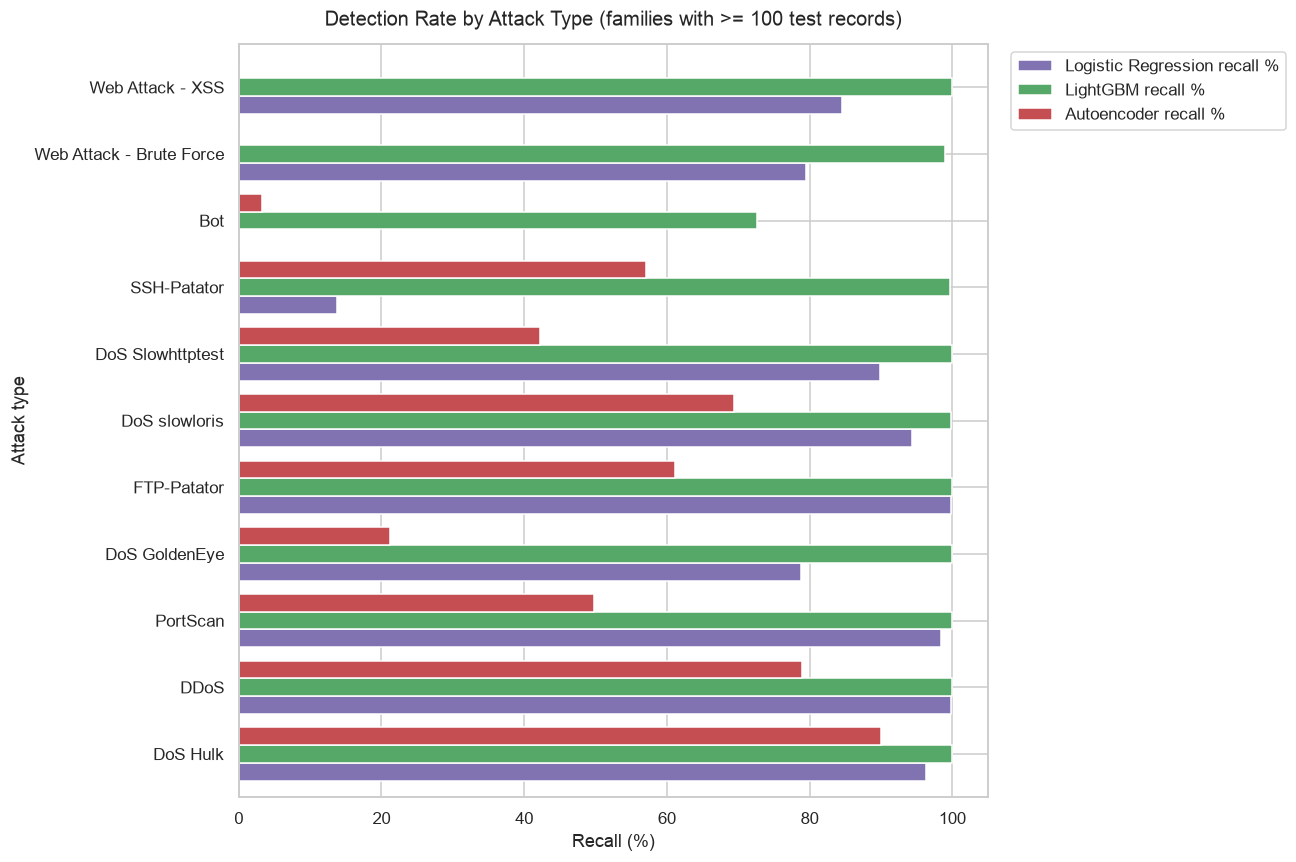

In [50]:
# Visualise only families with enough test records for the percentages to be meaningful.
MIN_RECORDS_FOR_PLOT = 100
plottable = per_attack_recall[
    per_attack_recall["Test records"] >= MIN_RECORDS_FOR_PLOT
].set_index("Attack type")

recall_columns = [c for c in plottable.columns if c.endswith("recall %")]

axis = plottable[recall_columns].plot(
    kind="barh", figsize=(12, 8), width=0.8,
    color=["#8172B2", "#55A868", "#C44E52"]
)
axis.set_xlabel("Recall (%)")
axis.set_ylabel("Attack type")
axis.set_xlim(0, 105)
axis.set_title(
    f"Detection Rate by Attack Type (families with >= {MIN_RECORDS_FOR_PLOT} test records)",
    fontsize=13, pad=12,
)
axis.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "figure12_per_attack_recall.png", dpi=300, bbox_inches="tight")
plt.show()

*Output: families with very few test records produce percentages that swing wildly between models and should not be read as capability.*

## I.1 Exploratory classifier-only attack-family exclusion
This analysis removes FTP-Patator from classifier fitting and LightGBM early-stopping validation only. Shared feature selection and preprocessing were fitted earlier on training data that included this family. Original validation-tuned thresholds are retained, so the comparison also reflects threshold transfer after retraining.

The family was chosen after inspecting earlier results. This is a retrospective sensitivity analysis, not an unbiased zero-day benchmark. The Autoencoder weights remain unchanged, but its preprocessing and F1 threshold are not attack-independent. A strict unseen-family experiment requires a separate, fully refitted pipeline and family-free threshold calibration.

**Threshold sources compared in the table below**

| Threshold source | Saw FTP-Patator labels? |
|---|---|
| Original validation F1 threshold | Yes (validation contains the family) |
| Re-tuned F1 threshold on family-free validation | No |
| Benign-validation 95th percentile (Autoencoder only) | No attack labels at all |

Remaining exposure in every row: feature selection, the imputer and the quantile transformer were fitted on training data that included FTP-Patator, and the family was chosen after inspecting earlier results.

In [51]:
# Recover the original attack labels for the training rows.
labels_train = original_labels.iloc[train_idx].values

held_out_mask_train = labels_train == HELD_OUT_ATTACK
n_held_out_train = int(held_out_mask_train.sum())

print(f"Held-out attack family : {HELD_OUT_ATTACK}")
print(f"Training rows removed  : {n_held_out_train:,}")

if n_held_out_train == 0:
    raise ValueError(
        f"'{HELD_OUT_ATTACK}' not found in the training split. "
        "Check the spelling against original_labels.value_counts()."
    )

# Keep every row except those belonging to the held-out family.
keep_mask = ~held_out_mask_train

X_train_tree_holdout = X_train_tree[keep_mask]
X_train_scaled_holdout = X_train_scaled[keep_mask]
y_train_holdout = y_train.values[keep_mask]

print(f"Training rows retained : {len(y_train_holdout):,}")
print(f"Attack rate in reduced training set: {y_train_holdout.mean():.2%}")

Held-out attack family : FTP-Patator
Training rows removed  : 3,672
Training rows retained : 1,508,907
Attack rate in reduced training set: 16.66%


In [52]:
# Retrain both supervised models on data that excludes the held-out family.
print("Retraining Logistic Regression...")
logistic_holdout = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
logistic_holdout.fit(X_train_scaled_holdout, y_train_holdout)

print("Retraining LightGBM...")
holdout_pos_weight = (y_train_holdout == 0).sum() / (y_train_holdout == 1).sum()

lightgbm_holdout = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=holdout_pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

# Validation set also excludes the held-out family, so early stopping cannot
# indirectly learn from it.
val_keep_mask = original_labels.iloc[val_idx].values != HELD_OUT_ATTACK

lightgbm_holdout.fit(
    X_train_tree_holdout,
    y_train_holdout,
    eval_set=[(X_val_tree[val_keep_mask], y_val.values[val_keep_mask])],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(50, first_metric_only=True, verbose=False)],
)

print(f"\nRetraining complete. LightGBM used {lightgbm_holdout.best_iteration_} trees.")

Retraining Logistic Regression...
Retraining LightGBM...


/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



Retraining complete. LightGBM used 333 trees.


In [53]:
# Evaluation set: the held-out attack family plus all benign test traffic.
# Benign flows are included to report precision and false alarms alongside family recall.
held_out_test_mask = (labels_test == HELD_OUT_ATTACK).values
benign_test_mask = (y_test.values == 0)
evaluation_mask = held_out_test_mask | benign_test_mask

X_eval_tree = X_test_tree[evaluation_mask]
X_eval_scaled = X_test_scaled[evaluation_mask]
y_eval = y_test.values[evaluation_mask]

print(f"Evaluation set: {evaluation_mask.sum():,} flows")
print(f"  {HELD_OUT_ATTACK} : {held_out_test_mask.sum():,}")
print(f"  Benign      : {benign_test_mask.sum():,}")

Evaluation set: 420,273 flows
  FTP-Patator : 1,115
  Benign      : 419,158


In [54]:
# Compare threshold sources: original, re-tuned on family-free validation, and label-free (Autoencoder).
def held_out_recall(scores, threshold, attack_mask_within_eval):
    """Recall (%) on the held-out attack family only."""
    predictions = (scores >= threshold).astype(int)
    attack_predictions = predictions[attack_mask_within_eval]
    return attack_predictions.sum() / len(attack_predictions) * 100

# Position of held-out attack rows inside the evaluation subset.
attack_within_eval = held_out_test_mask[evaluation_mask]

# --- Scores on the evaluation subset (held-out family + all benign test flows) ---
logistic_holdout_scores = logistic_holdout.predict_proba(X_eval_scaled)[:, 1]
lightgbm_holdout_scores = lightgbm_holdout.predict_proba(X_eval_tree)[:, 1]
autoencoder_eval_scores = compute_reconstruction_error(autoencoder, X_eval_scaled)
logistic_original_scores = logistic_test_scores[evaluation_mask]
lightgbm_original_scores = lightgbm_test_scores[evaluation_mask]

# --- Thresholds re-tuned on validation with the family removed (val_keep_mask from the retraining cell) ---
y_val_family_free = y_val.values[val_keep_mask]
family_free_thresholds = {
    "Logistic Regression": find_best_f1_threshold(
        y_val_family_free, logistic_holdout.predict_proba(X_val_scaled[val_keep_mask])[:, 1])[0],
    "LightGBM": find_best_f1_threshold(
        y_val_family_free, lightgbm_holdout.predict_proba(X_val_tree[val_keep_mask])[:, 1])[0],
    "Autoencoder": find_best_f1_threshold(
        y_val_family_free, autoencoder_val_scores[val_keep_mask])[0],
}

rows = [
    ("Logistic Regression", "Yes", "original validation F1", logistic_original_scores, thresholds["Logistic Regression"]),
    ("Logistic Regression", "No", "original validation F1 (transferred)", logistic_holdout_scores, thresholds["Logistic Regression"]),
    ("Logistic Regression", "No", "family-free validation F1", logistic_holdout_scores, family_free_thresholds["Logistic Regression"]),
    ("LightGBM", "Yes", "original validation F1", lightgbm_original_scores, thresholds["LightGBM"]),
    ("LightGBM", "No", "original validation F1 (transferred)", lightgbm_holdout_scores, thresholds["LightGBM"]),
    ("LightGBM", "No", "family-free validation F1", lightgbm_holdout_scores, family_free_thresholds["LightGBM"]),
    ("Autoencoder", "Weights: No", "original validation F1", autoencoder_eval_scores, thresholds["Autoencoder"]),
    ("Autoencoder", "Weights: No", "family-free validation F1", autoencoder_eval_scores, family_free_thresholds["Autoencoder"]),
    ("Autoencoder", "Weights: No", "benign validation P95 (no attack labels)", autoencoder_eval_scores, unsupervised_threshold),
]

table_rows = []
for model_name, saw_family, threshold_source, scores, threshold in rows:
    metrics = evaluate_model(model_name, y_eval, scores, threshold, verbose=False)
    table_rows.append({
        "Model": model_name,
        "Family in classifier training": saw_family,
        "Threshold source": threshold_source,
        "Threshold": threshold,
        f"Recall on {HELD_OUT_ATTACK} (%)": round(held_out_recall(scores, threshold, attack_within_eval), 2),
        "Precision": round(metrics["Precision"], 6),
        "FPR": round(metrics["FPR"], 6),
        "FP": metrics["FP"],
        "FN": metrics["FN"],
    })

holdout_comparison = pd.DataFrame(table_rows)
heldout_operating_metrics = holdout_comparison  # kept for the artifact-saving cell
recall_column = f"Recall on {HELD_OUT_ATTACK} (%)"
holdout_comparison

E0000 00:00:1790546701.570421  575793 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Model,Family in classifier training,Threshold source,Threshold,Recall on FTP-Patator (%),Precision,FPR,FP,FN
0,Logistic Regression,Yes,original validation F1,0.713471,99.82,0.144809,0.015681,6573,2
1,Logistic Regression,No,original validation F1 (transferred),0.713471,99.28,0.146081,0.015438,6471,8
2,Logistic Regression,No,family-free validation F1,0.719604,99.28,0.148591,0.015133,6343,8
3,LightGBM,Yes,original validation F1,0.846680,99.91,0.870993,0.000394,165,1
4,LightGBM,No,original validation F1 (transferred),0.846680,10.04,0.425856,0.000360,151,1003
5,LightGBM,No,family-free validation F1,0.868146,2.42,0.164634,0.000327,137,1088
6,Autoencoder,Weights: No,original validation F1,0.001953,61.08,0.049784,0.031010,12998,434
7,Autoencoder,Weights: No,family-free validation F1,0.001998,52.91,0.045350,0.029631,12420,525
8,Autoencoder,Weights: No,benign validation P95 (no attack labels),0.001544,99.01,0.049440,0.050640,21226,11


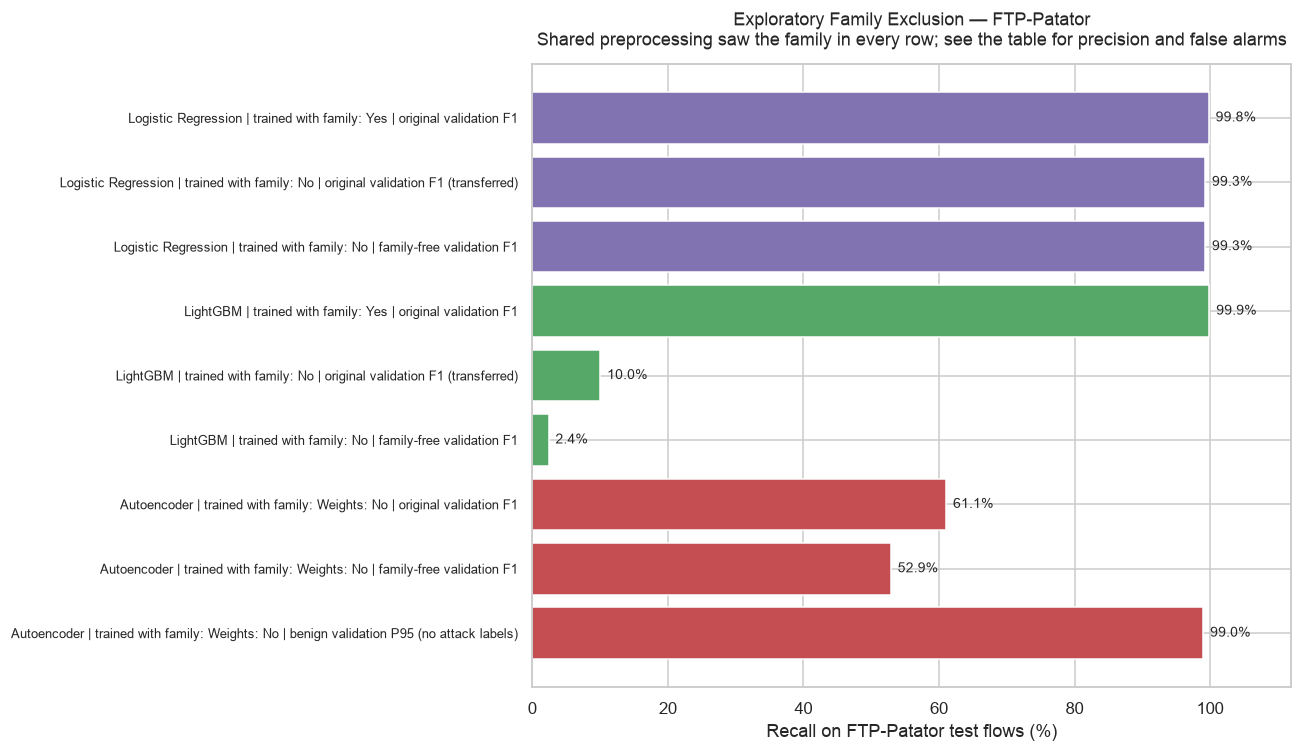

In [55]:
bar_labels = [
    f"{row.Model} | trained with family: {row._2} | {row._3}"
    for row in holdout_comparison.itertuples()
]
model_colors = {"Logistic Regression": "#8172B2", "LightGBM": "#55A868", "Autoencoder": "#C44E52"}
colors = [model_colors[name] for name in holdout_comparison["Model"]]

fig, axis = plt.subplots(figsize=(12, 7))
positions = np.arange(len(holdout_comparison))[::-1]
axis.barh(positions, holdout_comparison[recall_column], color=colors)
axis.set_yticks(positions, bar_labels, fontsize=8.5)
axis.set_xlim(0, 112)
axis.set_xlabel(f"Recall on {HELD_OUT_ATTACK} test flows (%)")
axis.set_title(
    f"Exploratory Family Exclusion — {HELD_OUT_ATTACK}\n"
    "Shared preprocessing saw the family in every row; see the table for precision and false alarms",
    fontsize=12, pad=12,
)
for position, value in zip(positions, holdout_comparison[recall_column]):
    axis.text(value + 1, position, f"{value:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure13_exploratory_family_exclusion.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
print("=" * 78)
print(f"EXPLORATORY FAMILY EXCLUSION — {HELD_OUT_ATTACK} (recall %, FP on benign test flows)")
print("=" * 78)
for row in holdout_comparison.itertuples(index=False):
    print(f"{row[0]:<20} trained with family: {row[1]:<12} {row[2]:<42} "
          f"{row[4]:6.2f}%  FP={row[7]:,}")
print("=" * 78)

EXPLORATORY FAMILY EXCLUSION — FTP-Patator (recall %, FP on benign test flows)
Logistic Regression  trained with family: Yes          original validation F1                      99.82%  FP=6,573
Logistic Regression  trained with family: No           original validation F1 (transferred)        99.28%  FP=6,471
Logistic Regression  trained with family: No           family-free validation F1                   99.28%  FP=6,343
LightGBM             trained with family: Yes          original validation F1                      99.91%  FP=165
LightGBM             trained with family: No           original validation F1 (transferred)        10.04%  FP=151
LightGBM             trained with family: No           family-free validation F1                    2.42%  FP=137
Autoencoder          trained with family: Weights: No  original validation F1                      61.08%  FP=12,998
Autoencoder          trained with family: Weights: No  family-free validation F1                   52.91%  FP=12,4

*Interpret these as retrospective classifier-exclusion results using shared preprocessing and transferred thresholds; they do not establish zero-day detection capability.*

*Rows with family-free or label-free thresholds remove the threshold exposure but not the preprocessing exposure. Recall on a single family with ~1,100 test flows, chosen after the fact, is a sensitivity check rather than a benchmark.*

---
# Section J — Final Model Report

The model was selected in Section F using validation average precision only. Recall, FPR and per-family coverage are reported as diagnostics, not additional implemented selection rules. Test results do not change the model or threshold.

In [57]:
# Report test metrics for the model already selected on validation.
best_model_row = comparison.loc[comparison["Model"] == best_model_name].iloc[0]

print("=" * 62)
print("FINAL MODEL SELECTION")
print("=" * 62)
print(f"Selected model : {best_model_name}")
print(f"Threshold      : {best_model_row['Threshold']:.6f}")
print("-" * 62)
for metric in ["Precision", "Recall", "F1", "AP", "ROC-AUC", "FPR", "FNR"]:
    print(f"  {metric:<10}: {best_model_row[metric]:.6f}")
print("-" * 62)
print(f"Attacks detected : {best_model_row['TP']:,} of {best_model_row['TP'] + best_model_row['FN']:,}")
print(f"Attacks missed   : {best_model_row['FN']:,}")
print(f"False alarms     : {best_model_row['FP']:,} of {best_model_row['FP'] + best_model_row['TN']:,}")
print("=" * 62)

FINAL MODEL SELECTION
Selected model : LightGBM
Threshold      : 0.846680
--------------------------------------------------------------
  Precision : 0.998060
  Recall    : 0.998318
  F1        : 0.998189
  AP        : 0.999939
  ROC-AUC   : 0.999982
  FPR       : 0.000394
  FNR       : 0.001682
--------------------------------------------------------------
Attacks detected : 84,893 of 85,036
Attacks missed   : 143
False alarms     : 165 of 419,158


---
# Section K — Saving Artifacts
LightGBM uses the saved median imputer only. Logistic Regression and the Autoencoder use the imputer followed by the quantile transformer. Inference must strip column whitespace, select the recorded features in order and replace infinities with NaN before transformation.

Models are stored separately from result tables. The configuration records input identity, settings and library versions; exact reproduction also depends on the runtime environment.

In [58]:
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# --- Models ---
joblib.dump(logistic_model, OUTPUT_DIR / "logistic_regression.pkl")
joblib.dump(lightgbm_model, OUTPUT_DIR / "lightgbm.pkl")
autoencoder.save(OUTPUT_DIR / "autoencoder.keras")

# --- Preprocessing objects (required for inference) ---
joblib.dump(imputer, OUTPUT_DIR / "imputer.pkl")
joblib.dump(quantile_transformer, OUTPUT_DIR / "quantile_transformer.pkl")

# --- Result tables ---
comparison.to_csv(TABLES_DIR / "model_comparison.csv", index=False)
operational.to_csv(TABLES_DIR / "operational_counts.csv", index=False)
per_attack_recall.to_csv(TABLES_DIR / "per_attack_recall.csv", index=False)
threshold_sweep.to_csv(TABLES_DIR / "threshold_sweep.csv", index=False)
overfitting_check.to_csv(TABLES_DIR / "overfitting_check.csv", index=False)
validation_comparison.to_csv(TABLES_DIR / "validation_comparison.csv", index=False)
operating_points.to_csv(TABLES_DIR / "operating_points.csv", index=False)
autoencoder_operating_points.to_csv(TABLES_DIR / "autoencoder_operating_points.csv", index=False)
pd.DataFrame(bottleneck_results).to_csv(TABLES_DIR / "exploratory_bottleneck.csv", index=False)
holdout_comparison.to_csv(TABLES_DIR / "exploratory_family_exclusion.csv", index=False)
split_summary.to_csv(TABLES_DIR / "split_summary.csv", index=False)
reduction_summary.to_csv(TABLES_DIR / "feature_reduction.csv", index=False)
pd.DataFrame([{
    "Rows in prepared file": rows_before,
    "Removed as repeated copies": n_repeated,
    "Removed as label-conflicting rows": n_conflicting_rows,
    "Label-conflicting patterns": n_conflicting_patterns,
    "Rows modelled": len(y_train) + len(y_val) + len(y_test),
}]).to_csv(TABLES_DIR / "data_filtering_summary.csv", index=False)

# --- Reproducibility record ---
config = {
    "data_file": CLEANED_FILE,
    "data_sha256": DATA_SHA256,
    "python_version": platform.python_version(),
    "library_versions": LIBRARY_VERSIONS,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "validation_fraction_of_remaining": VAL_SIZE,
    "rows_after_filtering": len(y_train) + len(y_val) + len(y_test),
    "task": "binary classification (benign vs attack)",
    "selection_metric": "validation average precision",
    "final_model": best_model_name,
    "thresholds_validation_f1": thresholds,
    "recall_oriented_threshold_lightgbm_f2": recall_oriented_threshold,
    "autoencoder_benign_p95_threshold": unsupervised_threshold,
    "family_exclusion": {"family": HELD_OUT_ATTACK, "family_free_thresholds": family_free_thresholds},
    "n_features": len(FEATURE_NAMES),
    "features": FEATURE_NAMES,
    "dropped_leaky": dropped_leaky,
    "dropped_constant": constant_features,
    "dropped_redundant": redundant_features,
    "correlation_threshold": CORRELATION_THRESHOLD,
    "bottleneck_size": BOTTLENECK_SIZE,
    "ae_epochs": AE_EPOCHS,
    "ae_batch_size": AE_BATCH_SIZE,
    "logistic_parameters": logistic_model.get_params(),
    "lightgbm_parameters": lightgbm_model.get_params(),
    "lightgbm_best_iteration": lightgbm_model.best_iteration_,
}

with open(OUTPUT_DIR / "config.json", "w") as config_file:
    json.dump(config, config_file, indent=2,
              default=lambda value: value.item() if isinstance(value, np.generic) else str(value))

for directory in (OUTPUT_DIR, TABLES_DIR):
    print(f"{directory.relative_to(PROJECT_ROOT)}/")
    for saved_file in sorted(p for p in directory.iterdir() if p.is_file()):
        print(f"  - {saved_file.name}")

models/
  - README.md
  - autoencoder.keras
  - config.json
  - imputer.pkl
  - lightgbm.pkl
  - logistic_regression.pkl
  - quantile_transformer.pkl
results/model_development/tables/
  - autoencoder_operating_points.csv
  - data_filtering_summary.csv
  - exploratory_bottleneck.csv
  - exploratory_family_exclusion.csv
  - feature_reduction.csv
  - model_comparison.csv
  - operating_points.csv
  - operational_counts.csv
  - overfitting_check.csv
  - per_attack_recall.csv
  - split_summary.csv
  - threshold_sweep.csv
  - validation_comparison.csv


In [59]:
print("=" * 62)
print("PROJECT SUMMARY")
print("=" * 62)
print(f"Dataset          : CIC-IDS2017")
print(f"Total records    : {len(y_train) + len(y_val) + len(y_test):,}")
print(f"Train/Val/Test   : {len(y_train):,} / {len(y_val):,} / {len(y_test):,}")
print(f"Features used    : {len(FEATURE_NAMES)}")
print(f"Attack rate      : {y_test.mean():.2%}")
print("-" * 62)
print("Models evaluated : Logistic Regression, LightGBM, Autoencoder")
print(f"Final model      : {best_model_name}")
print(f"Test AP      : {best_model_row['AP']:.6f}")
print(f"Test recall      : {best_model_row['Recall']:.6f}")
print(f"Test FPR         : {best_model_row['FPR']:.6f}")
print("=" * 62)

PROJECT SUMMARY
Dataset          : CIC-IDS2017
Total records    : 2,520,966
Train/Val/Test   : 1,512,579 / 504,193 / 504,194
Features used    : 44
Attack rate      : 16.87%
--------------------------------------------------------------
Models evaluated : Logistic Regression, LightGBM, Autoencoder
Final model      : LightGBM
Test AP      : 0.999939
Test recall      : 0.998318
Test FPR         : 0.000394


---
## Interpreting the results

Read the numbers from the tables written in Section K:
- `model_comparison.csv` / `autoencoder_operating_points.csv`: test-set performance at validation-selected thresholds.
- `per_attack_recall.csv`: recall per attack family; ignore families with very few test flows.
- `exploratory_family_exclusion.csv`: how much each model depends on having seen FTP-Patator in training. Compare recall **and** false alarms.
- `exploratory_bottleneck.csv`: single-seed, preliminary; small AP differences are not meaningful.

Keep in mind the capture structure documented in notebook 01, Section 18b: every attack family comes from a single capture day, most families use one destination port, and `Init_Win_bytes_forward = -1` occurs almost only in benign traffic. Very high scores on a random split partly reflect this structure.

## Limitations
- Similar train/test metrics do not prove absence of leakage or generalisation beyond this random split.
- The data is from 2017; the split is random rather than chronological or session-grouped; features are flow-level only; duplicate/label-conflicting patterns were removed using labels before splitting, so metrics describe that filtered population.
- Rare families (Infiltration 7, SQL Injection 6, Heartbleed 1 test flows) cannot support any per-family claim.
- Cleaning decisions made before this notebook (infinity and impossible-negative handling, label normalisation) are documented in notebook 01.
- Explanations involving encryption, HTTP-like behaviour or representational limits are hypotheses unless supported by additional evidence.

Future work: evaluate chronological or capture-day-grouped splits; repeat the Autoencoder and exclusion experiments over several seeds and families; build a fully isolated unseen-family pipeline (feature selection and preprocessing refitted without the family).

---
# Section L — Export tables and figures for the report

All result tables (`results/model_development/tables/*.csv`) and figures (`results/model_development/figures/*.png`) are collected in `results/model_development/report_assets.html`. Open it in a browser, select a table or figure, copy, and paste it into the report.

In [60]:
# Build one HTML page with every saved table and figure, ready to copy into the report.
import html as html_lib


def _format_number(value):
    return f"{value:,.0f}" if abs(value) >= 1000 else f"{value:.6g}"


def build_report_assets(results_dir, title):
    parts = [
        f"<h1>{html_lib.escape(title)}</h1>",
        "<p><b>Tables:</b> select a table, copy it and paste it into Word or Google Docs. "
        "<b>Figures:</b> right-click an image and copy it, or insert the PNG files from the "
        "<code>figures/</code> folder.</p>",
        "<h2>Tables</h2>",
    ]
    for csv_path in sorted((results_dir / "tables").glob("*.csv")):
        table = pd.read_csv(csv_path)
        parts.append(f"<h3>{html_lib.escape(csv_path.stem)}</h3>")
        parts.append(table.to_html(index=False, border=1, na_rep="", float_format=_format_number))
    parts.append("<h2>Figures</h2>")
    for png_path in sorted((results_dir / "figures").glob("*.png")):
        parts.append(f"<h3>{html_lib.escape(png_path.stem)}</h3>")
        parts.append(f'<img src="figures/{png_path.name}" alt="{png_path.stem}" style="max-width:100%;">')

    style = (
        "body{font-family:Arial,sans-serif;margin:24px;}"
        "table{border-collapse:collapse;font-size:12px;margin-bottom:24px;}"
        "th,td{border:1px solid #999;padding:4px 8px;text-align:right;}"
        "th{background:#eee;}"
    )
    page = (
        f"<!doctype html><html><head><meta charset='utf-8'><title>{html_lib.escape(title)}</title>"
        f"<style>{style}</style></head><body>{''.join(parts)}</body></html>"
    )
    output_file = results_dir / "report_assets.html"
    output_file.write_text(page, encoding="utf-8")
    print("Open this file in a browser to copy tables and figures:", output_file.relative_to(PROJECT_ROOT))


build_report_assets(RESULTS_DIR, "CIC-IDS2017 — model development tables and figures")

Open this file in a browser to copy tables and figures: results/model_development/report_assets.html
